> Repository edition: outputs below are the supplied capstone results. Paths and scope wording have been revised. A fresh run writes separate outputs under reports/generated. Full-data EDA preceded the split; therefore the held-out evaluation is not completely insulated from human exploratory choices.


# Predicting Student Dropout and Academic Success: A Machine Learning Model

by: Al Christian Gobres, September 2026

This study develops a machine learning model to predict student academic outcomes, with particular focus on identifying students who are at risk of dropping out and those likely to achieve academic success. Using available student demographic, socioeconomic, enrollment, and academic performance data, the analysis aims to uncover the factors most strongly associated with student outcomes and evaluate the predictive performance of different machine learning approaches. The resulting model is intended to support earlier identification of at-risk students and provide data-driven insights that may help educational institutions design more targeted academic support and intervention strategies.

## Table of Contents

- [Predicting Student Dropout and Academic Success: A Machine Learning Model](#predicting-student-dropout-and-academic-success-a-machine-learning-model)

### I. [Problem Understanding and Framing](#i-problem-understanding-and-framing)
- [1. Business and data science problem](#1-business-and-data-science-problem)
- [2. Type of machine learning task](#2-type-of-machine-learning-task)
- [3. Technical success metrics](#3-technical-success-metrics)
- [4. Business KPIs](#4-business-kpis)

### II. [Data Collection & Understanding](#ii-data-collection--understanding)
- [Dataset Source](#dataset-source)
- [Data Dictionary](#data-dictionary)

### III. [Data Preprocessing, Applied EDA & Feature Engineering](#iii-data-preprocessing-applied-eda--feature-engineering)
- [Target Variable](#target-variable)
- [EDA for Categorical Features](#eda-for-categorical-features)
- [EDA for Numerical Features](#eda-for-numerical-features)
  - [Descriptive Statistics and Data Quality](#descriptive-statistics-and-data-quality)
  - [Distribution of Numerical Features](#distribution-of-numerical-features)
  - [Potential Outliers](#potential-outliers)
  - [Numerical Features by Student Outcome](#numerical-features-by-student-outcome)
  - [Correlations Between Numerical Features](#correlations-between-numerical-features)
- [EDA Interpretation](#eda-interpretation)
- [Preprocessing and Feature Engineering](#preprocessing-and-feature-engineering)
- [Domain-Derived Features and Binning](#domain-derived-features-and-binning)
- [Applied EDA of Engineered Features](#applied-eda-of-engineered-features)
- [Preprocessing Pipeline](#preprocessing-pipeline)
- [Exploratory Feature Importance](#exploratory-feature-importance)
- [Embedded Feature Selection](#embedded-feature-selection)
- [Principal Component Analysis](#principal-component-analysis)
- [Inputs for Subsequent Model Comparison](#inputs-for-subsequent-model-comparison)

### IV. [Model Implementation](#iv-model-implementation)
- [Model Implementation and Comparison](#model-implementation-and-comparison)
- [Hyperparameter Search](#hyperparameter-search)
- [Cross-Validation and Validation Results](#cross-validation-and-validation-results)
- [Validation Error Analysis](#validation-error-analysis)
- [Model Selection](#model-selection)
- [Final Test Evaluation](#final-test-evaluation)
- [Model Results Interpretation](#model-results-interpretation)

### V. [Bias & Fairness Analysis](#v-bias--fairness-analysis)
- [Ethical AI, Explainability, and Fairness Audit](#ethical-ai-explainability-and-fairness-audit)
- [Partial Dependence and Individual Conditional Expectation](#partial-dependence-and-individual-conditional-expectation)
- [Interpretation of PDP and ICE Results](#interpretation-of-pdp-and-ice-results)
- [Sensitive Attributes and Audit Coverage](#sensitive-attributes-and-audit-coverage)
- [Fairness Metric Definitions](#fairness-metric-definitions)
- [Interpretation of the Fairness Audit](#interpretation-of-the-fairness-audit)
  - [Gender](#gender)
  - [Age](#age)
  - [Socioeconomic Proxies](#socioeconomic-proxies)
  - [Intersectional Patterns](#intersectional-patterns)
  - [Other Outcomes](#other-outcomes)
- [Mitigation Priorities Based on the Audit](#mitigation-priorities-based-on-the-audit)
- [Ethical AI Audit Conclusion](#ethical-ai-audit-conclusion)

## I. Problem Understanding and Framing

This subsection defines the business problem and translates it into a clear data science objective. It identifies the appropriate analytical task, such as classification, regression, recommendation, anomaly detection, or clustering, and establishes the criteria for evaluating success. Relevant model performance metrics (e.g., Accuracy, AUC, RMSE, or Silhouette Score) are specified alongside business KPIs, such as cost savings or uplift, to ensure that the technical solution remains aligned with the intended business outcomes.

### 1. Business and data science problem

Institutions need evidence to guide voluntary academic support. This study classifies the recorded outcomes **Dropout**, **Enrolled**, and **Graduate** using demographic, financial, entry, and first- and second-semester academic information. It is a retrospective classification study, not an enrollment-only early-warning evaluation.

A prospective use case requires a verified prediction date, feature timestamps, and eligibility criteria that exclude outcomes already known at that date. Enrolled remains a separate observed status with an unresolved eventual outcome. Outreach impact and return on investment have not been measured.


### 2. Type of machine learning task
This is a **supervised multiclass classification task**.
Each historical student record has one of three outcome labels:

| Class | Interpretation |
|---|---|
| Dropout | Recorded as having dropped out |
| Enrolled | Still enrolled at the observation point |
| Graduate | Recorded as having graduated |

A separate outreach policy will use the predicted probability of Dropout to identify students for contact. This policy is distinct from the model’s three-class prediction.

### 3. Technical success metrics
**Macro-F1** will be the primary model-selection metric. It gives equal importance to each outcome class, making it more suitable than accuracy alone when class sizes differ.

| Metric | Purpose |
|---|---|
| **Macro-F1** | Assess balanced predictive performance across all three classes |
| **Dropout recall** | Measure the proportion of recorded dropouts identified by the outreach policy |
| **Dropout precision** | Measure the proportion of alerted students whose recorded outcome is Dropout |
| **Average precision** | Assess dropout ranking performance across precision–recall thresholds |
| **Dropout ROC-AUC** | Assess how well scores distinguish recorded Dropout from the other outcomes |
| **Accuracy and confusion matrix** | Summarise overall correctness and errors between classes |
| **Subgroup fairness measures** | Compare alert rates, true-positive rates, and false-positive rates across Gender and age groups |

Models will be selected using stratified five-fold cross-validation on training data. Validation data will determine the outreach threshold and any mitigation decision. Final performance will be reported once on an untouched test set, with confidence intervals for key metrics.

Success means demonstrating improvement over a simple baseline while transparently reporting missed students, false alerts, workload, and subgroup disparities. Numerical performance targets should not be presented as achieved before evaluation.

### 4. Business KPIs

The immediate business objective is to make early outreach manageable and useful. Longer-term benefits require a prospective pilot.

| Business KPI | Measurement |
|---|---|
| **Outreach workload** | Number and percentage of students flagged; approximately **20%** is a hypothetical adviser-capacity assumption |
| **Support uptake** | Students accepting support ÷ students invited |
| **Adviser effort** | Staff hours required for outreach and follow-up |
| **Retention uplift** | Difference in retention rates between intervention and an appropriate comparison group at a defined follow-up time |
| **Dropout reduction** | Difference in dropout rates between intervention and comparison groups |
| **Cost-effectiveness** | Additional programme cost ÷ additional students retained, if an intervention benefit is established |

The historical dataset can evaluate predictive performance and estimate outreach workload. It cannot establish that outreach prevents dropout, improves retention, or produces financial savings. Those outcomes must be measured through a prospective intervention evaluation.

## II. Data Collection & Understanding

This subsection describes the data sources used for the analysis, which may include publicly available datasets, APIs, or approved custom data. It provides an initial assessment of the dataset by examining feature types, missing values, outliers, and other relevant data quality considerations. A data dictionary is also included to document each variable, its data type, unit of measurement, and allowable values, providing a clear reference for the succeeding stages of analysis.


### Dataset Source
**Source:** Realinho, V., Vieira Martins, M., Machado, J., & Baptista, L. (2021). Predict Students' Dropout and Academic Success [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5MC89.

The dataset was created in a project that aims to contribute to the reduction of academic dropout and failure in higher education, by using machine learning techniques to identify students at risk at an early stage of their academic path, so that strategies to support them can be put into place. 

The dataset includes information known at the time of student enrollment – academic path, demographics, and social-economic factors. 

The problem is formulated as a three category classification task (dropout, enrolled, and graduate) at the end of the normal duration of the course. 

In [1]:
import pandas as pd

In [2]:
data = pd.read_csv(
    ROOT / "data/raw/data.csv",
    sep=';'
)
data

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,1,1,6,9773,1,1,125.0,1,1,1,...,0,6,8,5,12.666667,0,15.5,2.8,-4.06,Graduate
4420,1,1,2,9773,1,1,120.0,105,1,1,...,0,6,6,2,11.000000,0,11.1,0.6,2.02,Dropout
4421,1,1,1,9500,1,1,154.0,1,37,37,...,0,8,9,1,13.500000,0,13.9,-0.3,0.79,Dropout
4422,1,1,1,9147,1,1,180.0,1,37,37,...,0,5,6,5,12.000000,0,9.4,-0.8,-3.12,Graduate


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

### Data Dictionary

In [4]:
# Use the checked-in dictionary for offline reproducibility.
# The original BeautifulSoup retrieval script is in src/student_dropout/scrape_dictionary.py.
print("Dictionary:", ROOT / "data/reference/variables_table.csv")


Saved 37 variables to variables_table.csv


In [5]:
data_dict = pd.read_csv(ROOT / "data/reference/variables_table.csv")

with pd.option_context(
    "display.max_rows", None,
    "display.max_columns", None,
    "display.max_colwidth", None,
):
    display(data_dict)  # Jupyter notebook

,Variable Name,Role,Type,Demographic,Description,Units,Missing Values
0,Marital Status,Feature,Integer,Marital Status,1 â single 2 â married 3 â widower 4 â divorced 5 â facto union 6 â legally separated,NaN,no
1,Application mode,Feature,Integer,NaN,"1 - 1st phase - general contingent 2 - Ordinance No. 612/93 5 - 1st phase - special contingent (Azores Island) 7 - Holders of other higher courses 10 - Ordinance No. 854-B/99 15 - International student (bachelor) 16 - 1st phase - special contingent (Madeira Island) 17 - 2nd phase - general contingent 18 - 3rd phase - general contingent 26 - Ordinance No. 533-A/99, item b2) (Different Plan) 27 - Ordinance No. 533-A/99, item b3 (Other Institution) 39 - Over 23 years old 42 - Transfer 43 - Change of course 44 - Technological specialization diploma holders 51 - Change of institution/course 53 - Short cycle diploma holders 57 - Change of institution/course (International)",NaN,no
2,Application order,Feature,Integer,NaN,Application order (between 0 - first choice; and 9 last choice),NaN,no
3,Course,Feature,Integer,NaN,33 - Biofuel Production Technologies 171 - Animation and Multimedia Design 8014 - Social Service (evening attendance) 9003 - Agronomy 9070 - Communication Design 9085 - Veterinary Nursing 9119 - Informatics Engineering 9130 - Equinculture 9147 - Management 9238 - Social Service 9254 - Tourism 9500 - Nursing 9556 - Oral Hygiene 9670 - Advertising and Marketing Management 9773 - Journalism and Communication 9853 - Basic Education 9991 - Management (evening attendance),NaN,no
4,Daytime/evening attendance,Feature,Integer,NaN,1 â daytime 0 - evening,NaN,no
5,Previous qualification,Feature,Integer,Education Level,1 - Secondary education 2 - Higher education - bachelor's degree 3 - Higher education - degree 4 - Higher education - master's 5 - Higher education - doctorate 6 - Frequency of higher education 9 - 12th year of schooling - not completed 10 - 11th year of schooling - not completed 12 - Other - 11th year of schooling 14 - 10th year of schooling 15 - 10th year of schooling - not completed 19 - Basic education 3rd cycle (9th/10th/11th year) or equiv. 38 - Basic education 2nd cycle (6th/7th/8th year) or equiv. 39 - Technological specialization course 40 - Higher education - degree (1st cycle) 42 - Professional higher technical course 43 - Higher education - master (2nd cycle),NaN,no
6,Previous qualification (grade),Feature,Continuous,NaN,Grade of previous qualification (between 0 and 200),NaN,no
7,Nacionality,Feature,Integer,Nationality,1 - Portuguese; 2 - German; 6 - Spanish; 11 - Italian; 13 - Dutch; 14 - English; 17 - Lithuanian; 21 - Angolan; 22 - Cape Verdean; 24 - Guinean; 25 - Mozambican; 26 - Santomean; 32 - Turkish; 41 - Brazilian; 62 - Romanian; 100 - Moldova (Republic of); 101 - Mexican; 103 - Ukrainian; 105 - Russian; 108 - Cuban; 109 - Colombian,NaN,no
8,Mother's qualification,Feature,Integer,Education Level,1 - Secondary Education - 12th Year of Schooling or Eq. 2 - Higher Education - Bachelor's Degree 3 - Higher Education - Degree 4 - Higher Education - Master's 5 - Higher Education - Doctorate 6 - Frequency of Higher Education 9 - 12th Year of Schooling - Not Completed 10 - 11th Year of Schooling - Not Completed 11 - 7th Year (Old) 12 - Other - 11th Year of Schooling 14 - 10th Year of Schooling 18 - General commerce course 19 - Basic Education 3rd Cycle (9th/10th/11th Year) or Equiv. 22 - Technical-professional course 26 - 7th year of schooling 27 - 2nd cycle of the general high school course 29 - 9th Year of Schooling - Not Completed 30 - 8th year of schooling 34 - Unknown 35 - Can't read or write 36 - Can read without having a 4th year of schooling 37 - Basic education 1st cycle (4th/5th year) or equiv. 38 - Basic Education 2nd Cycle (6th/7th/8th Year) or Equiv. 39 - Technological specialization course 40 - Higher education - degree (1st cycle) 41 - Specialized higher studies course 42 - Professional higher technical course 43 - Higher Educati

In [6]:
unique_counts = data.nunique().reset_index()
unique_counts.columns = ["Feature", "Unique Values"]

unique_counts

,Feature,Unique Values
0,Marital status,6
1,Application mode,18
2,Application order,8
3,Course,17
4,Daytime/evening attendance\t,2
5,Previous qualification,17
6,Previous qualification (grade),101
7,Nacionality,21
8,Mother's qualification,29
9,Father's qualification,34


In [7]:
data.describe()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


In [8]:
num_indices = [6, 12, 19, *range(21, 36)]
num_cols = data.columns[num_indices].tolist()
categ_cols = [col for col in data.columns if col not in num_cols]
categ_cols = [col for col in categ_cols if col != "Target"]

print('Numerical columns:', num_cols, '\n')
print('Categorical columns:', categ_cols)

Numerical columns: ['Previous qualification (grade)', 'Admission grade', 'Age at enrollment', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'GDP'] 

Categorical columns: ['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance\t', 'Previous qualification', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship hold

In [9]:
import numpy as np

## III. Data Preprocessing, Applied EDA & Feature Engineering 

This subsection covers the preparation and transformation of the dataset prior to modeling. It includes data cleaning procedures such as handling missing values, duplicates, and outliers, as well as feature engineering techniques such as scaling, encoding, binning, and the creation of domain-relevant variables. Applied exploratory data analysis is conducted to examine distributions, relationships, and clustering tendencies where applicable. The subsection also evaluates feature importance and model explainability using techniques such as SHAP, LIME, or model-based importance measures, applies at least one feature selection method, and uses dimensionality reduction techniques such as PCA, with t-SNE or UMAP where useful for visualization.

In [10]:
import math
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

### Target Variable

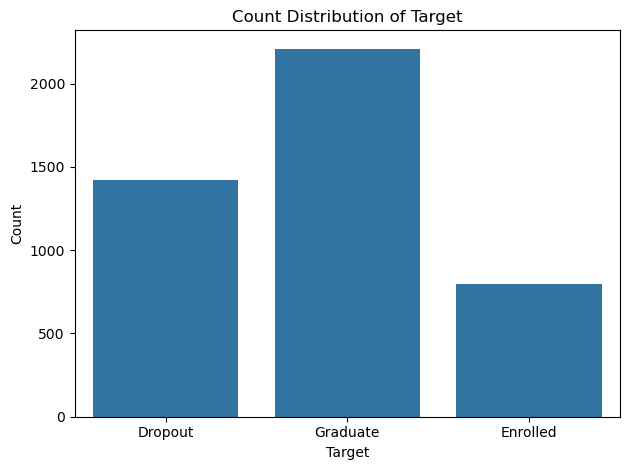

In [11]:
sns.countplot(data=data, x="Target")
plt.title("Count Distribution of Target")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("target_count_plot.png", dpi=300, bbox_inches="tight")
plt.show()

The plot shows an imbalanced target distribution:

| Outcome | Approximate count | Percentage |
|---|---:|---:|
| Graduate | 2,200 | 50% |
| Dropout | 1,400 | 32% |
| Enrolled | 800 | 18% |

Graduates make up about half the dataset, while enrolled students are the smallest group. Dropouts represent nearly one-third of students.

### EDA for Categorical Features

/tmp/ipykernel_5181/3280442629.py:18: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5181/3280442629.py:20: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.savefig("categorical_count_plots.png", dpi=300, bbox_inches="tight")
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


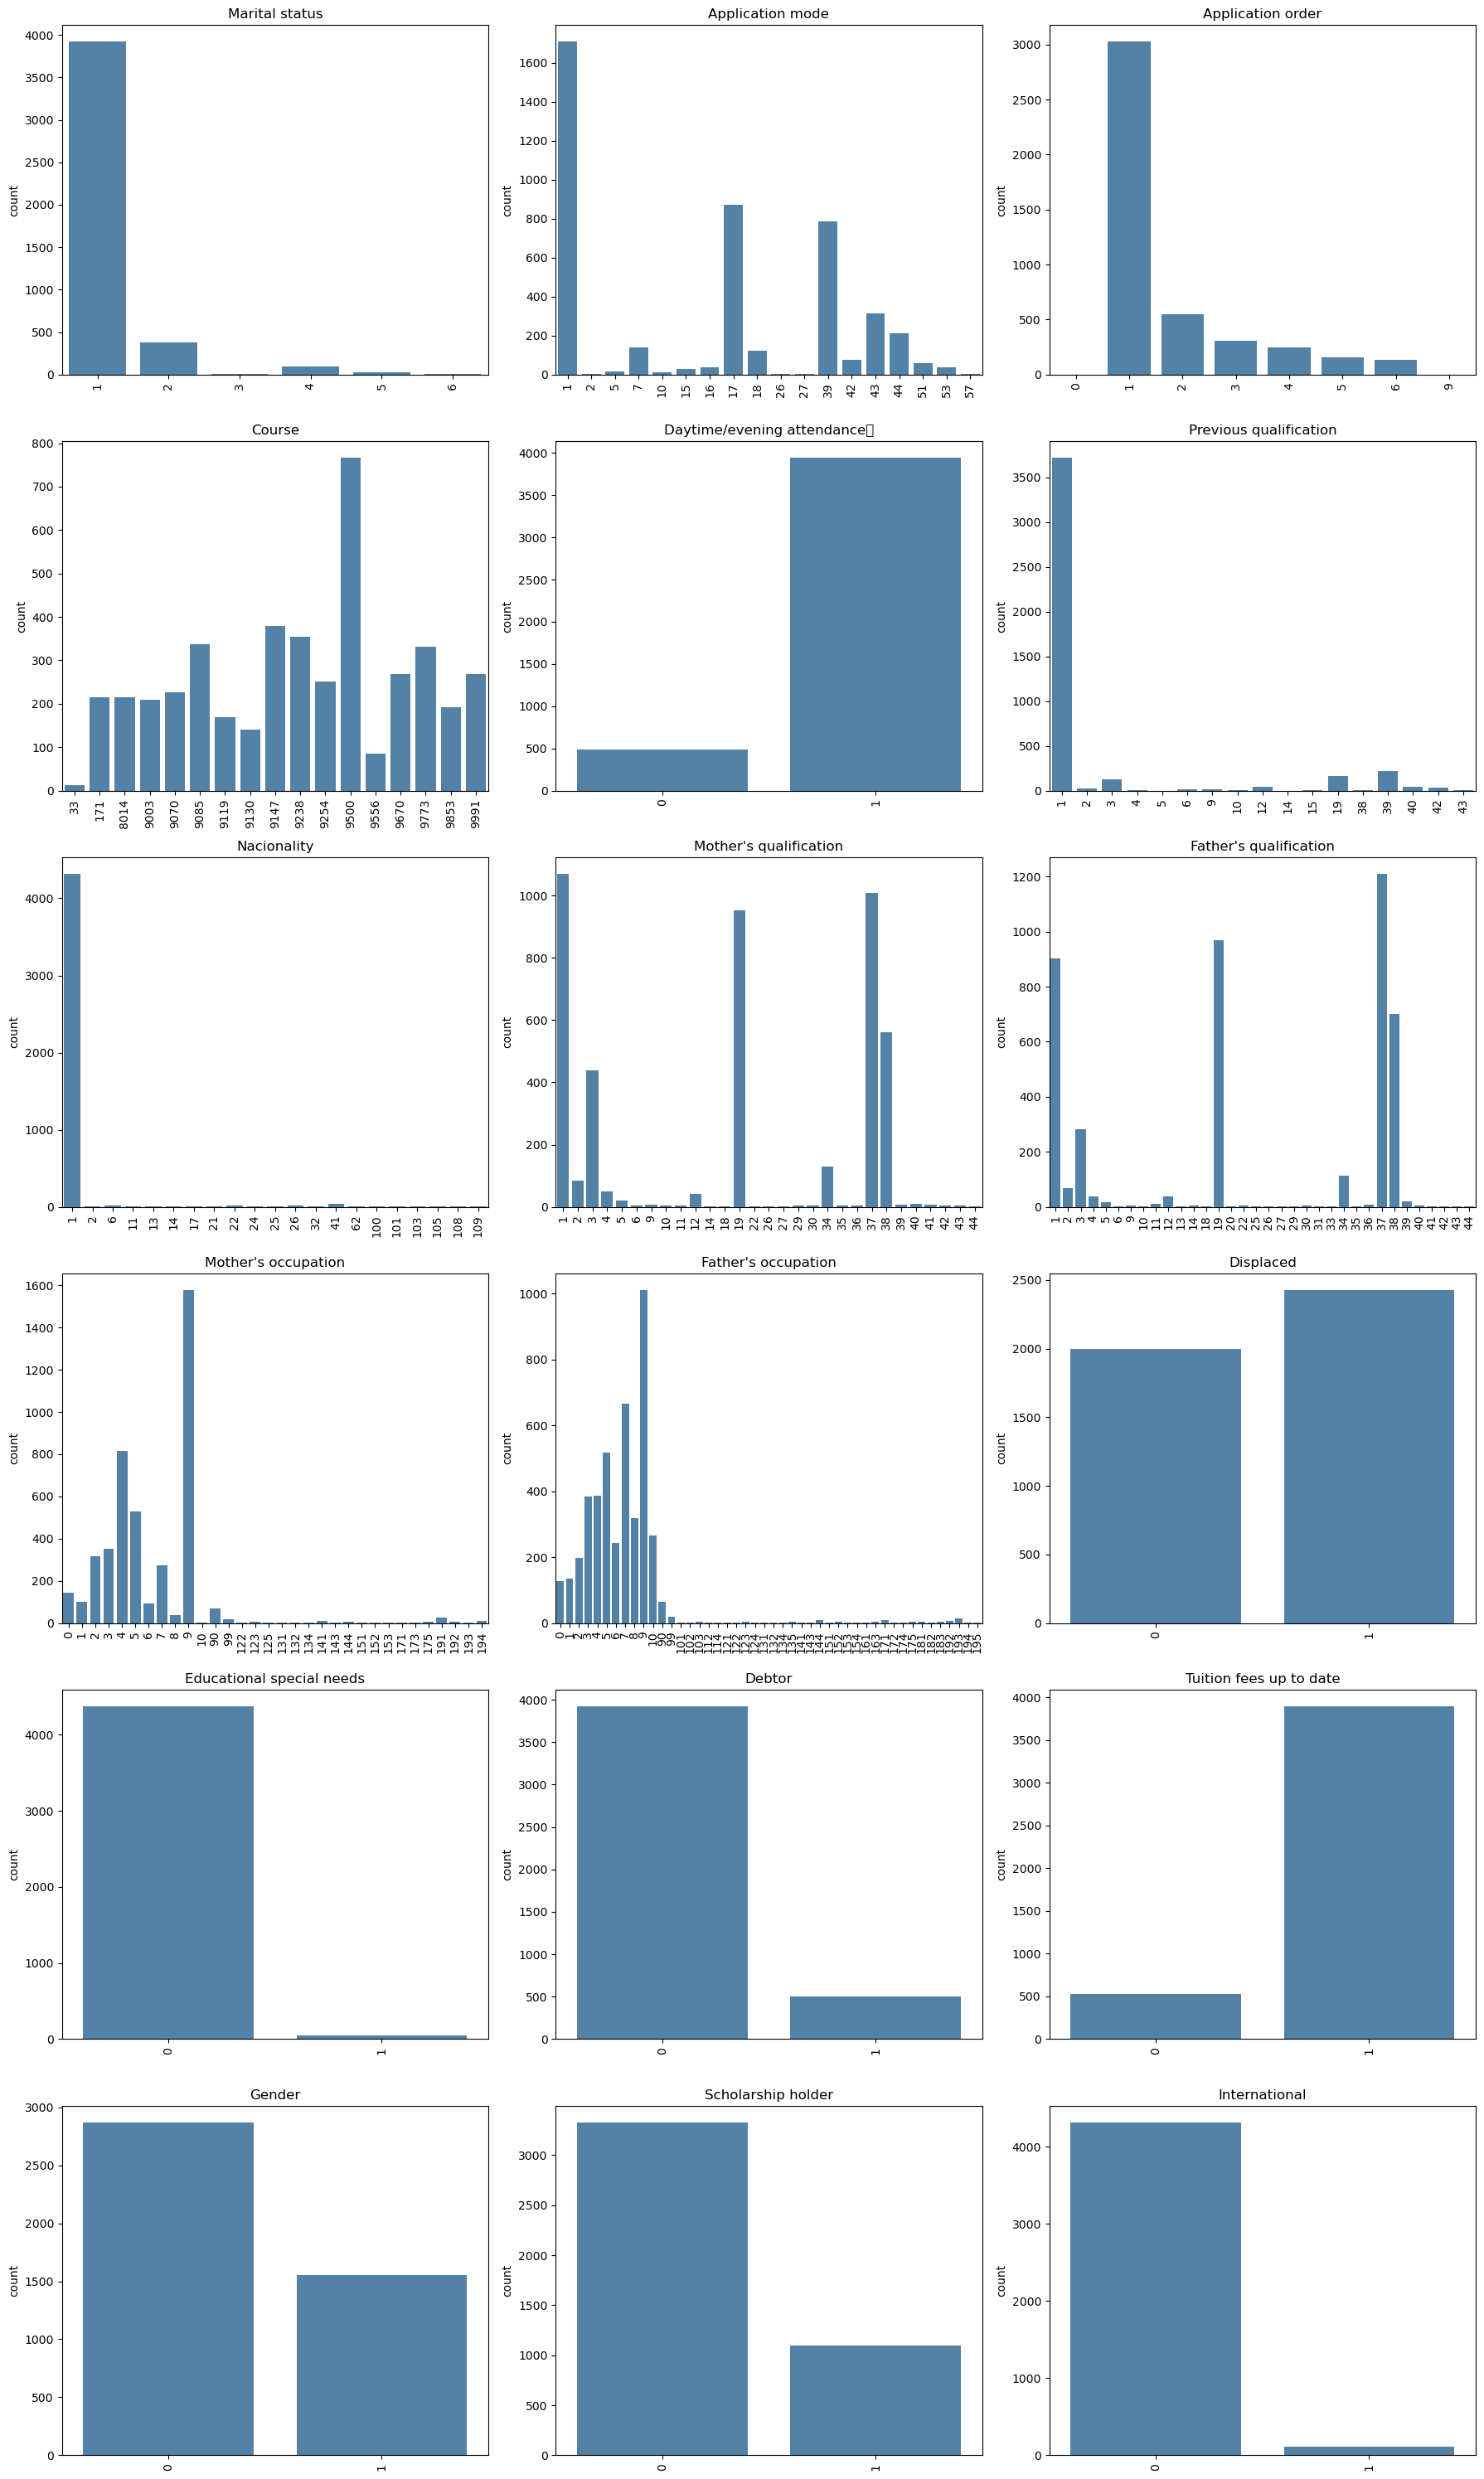

In [12]:
ncols = 3
nrows = math.ceil(len(categ_cols) / ncols)

fig, axes = plt.subplots(
    nrows, ncols, figsize=(18, 5 * nrows), squeeze=False
)

for ax, col in zip(axes.flat, categ_cols):
    sns.countplot(data=data, x=col, ax=ax, color="steelblue")
    ax.set_title(col)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=90)

# Hide unused subplots.
for ax in list(axes.flat)[len(categ_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.tight_layout()
fig.savefig("categorical_count_plots.png", dpi=300, bbox_inches="tight")
plt.show()

The plots show that many categorical variables are dominated by a single category, while course, parental background, and student outcomes are more varied.

| Variable(s) | Interpretation |
|---|---|
| **Marital status** | Most students are single (code 1), accounting for roughly 89% of the sample. Other marital statuses are relatively uncommon. |
| **Application mode** | Mode 1 is the most common, followed by modes 17 and 39. Several admission routes have very few students. |
| **Application order** | Most students entered a course ranked as their first choice (code 1). Higher application-order categories are progressively less common. |
| **Course** | Enrollment varies substantially by course. Code 9500—Nursing—has the largest enrollment, at around 770 students. |
| **Daytime/evening attendance** | Approximately 89% attend during the daytime (code 1); evening students form a much smaller group. |
| **Previous qualification** | Code 1—secondary education—dominates, indicating that most students entered with this qualification. |
| **Nationality and international status** | The sample is overwhelmingly Portuguese and non-international. Other nationalities have very small counts. |
| **Mother’s and father’s qualifications** | Qualifications are concentrated in a few categories, particularly codes 1, 19, 37, and 38. Many other qualification categories are rare. |
| **Mother’s and father’s occupations** | Code 9 is the largest group for both parents. Fathers’ occupations are more spread across the other common categories. |
| **Displaced** | This variable is relatively balanced, with slightly more students in category 1 (about 55%) than category 0. |
| **Educational special needs** | Almost all students are in category 0. The small number in category 1 limits how confidently this subgroup can be analysed. |
| **Debtor** | Most students are not debtors; roughly 11% are in the debtor category. |
| **Tuition fees up to date** | Around 88% have their tuition fees up to date. A smaller group has outstanding payments. |
| **Gender** | Category 0 accounts for about 65% of students, compared with approximately 35% in category 1. |
| **Scholarship holder** | Around one-quarter hold scholarships; most do not. |
| **Target** | Graduates are the largest group (about 50%), followed by dropouts (32%) and enrolled students (18%). The outcome classes are imbalanced. |

/tmp/ipykernel_5181/3108200760.py:40: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.tight_layout(rect=[0, 0, 1, 0.98])
/tmp/ipykernel_5181/3108200760.py:41: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.savefig("outcome_percentages_by_category.png", dpi=300, bbox_inches="tight")
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


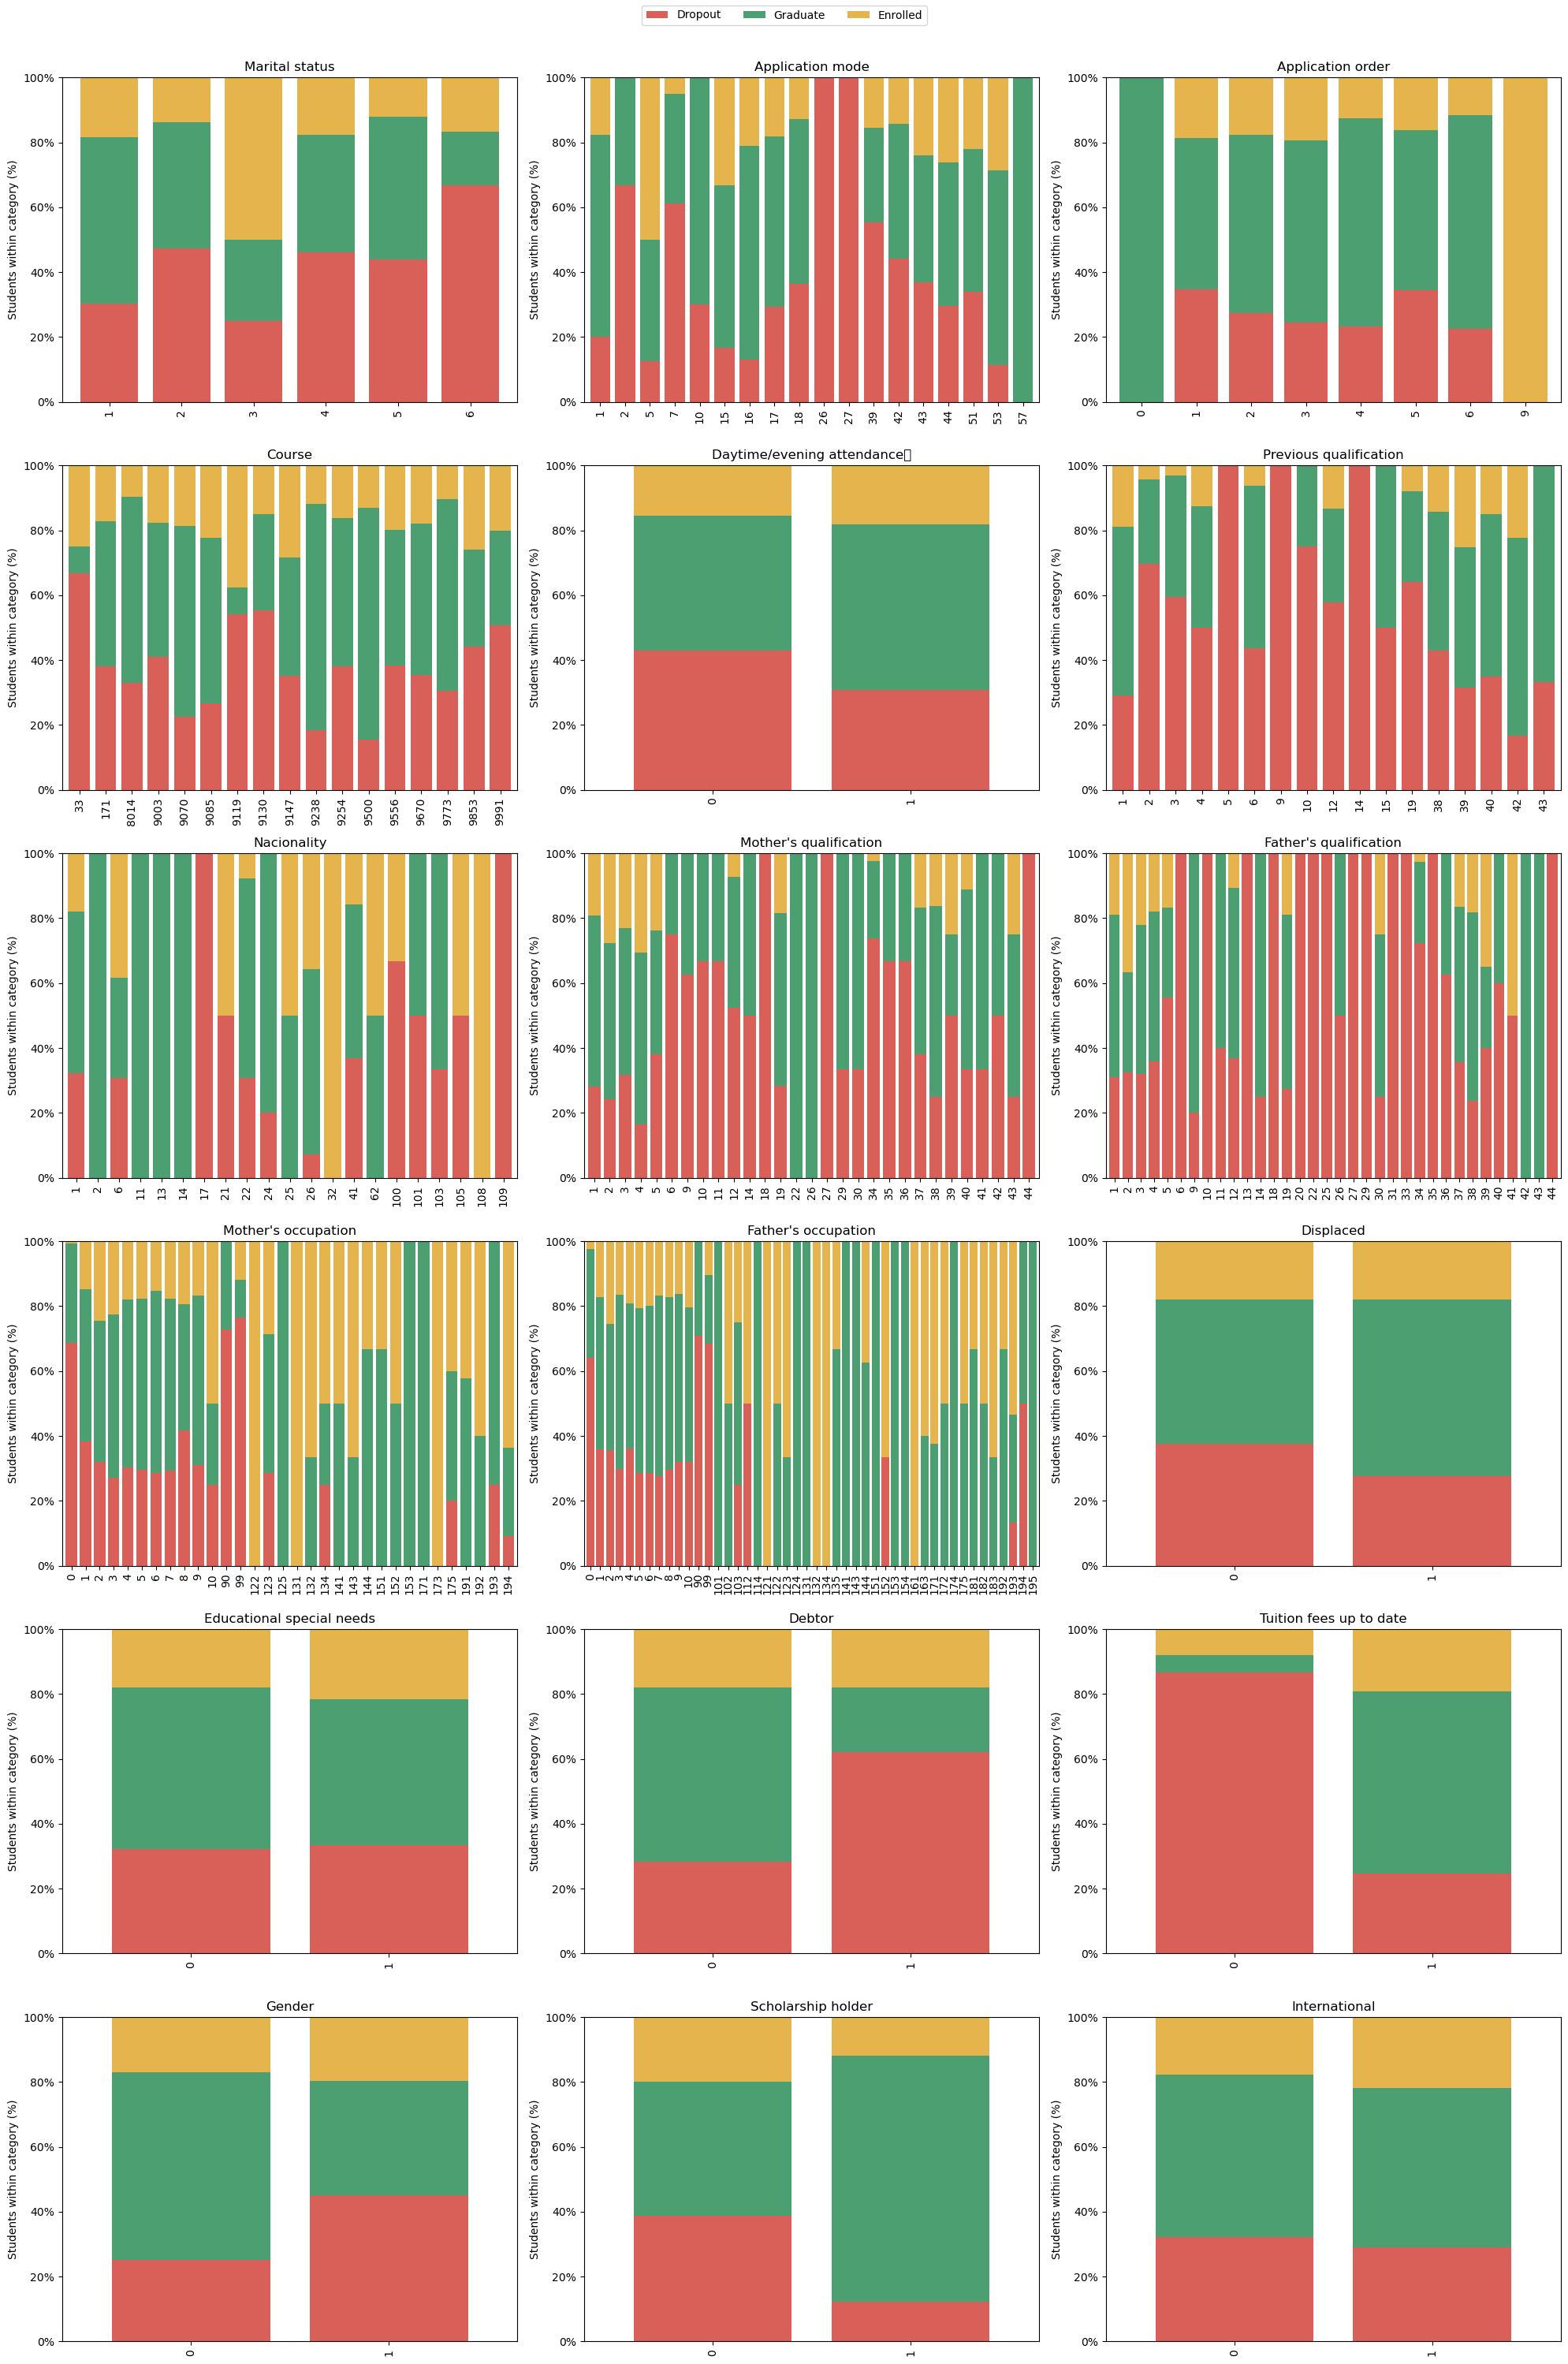

In [13]:
outcomes = ["Dropout", "Graduate", "Enrolled"]
colors = ["#d95f59", "#4c9f70", "#e5b44c"]

ncols = 3
nrows = math.ceil(len(categ_cols) / ncols)

fig, axes = plt.subplots(
    nrows, ncols, figsize=(20, 5 * nrows), squeeze=False
)

for ax, col in zip(axes.flat, categ_cols):
    percentages = (
        pd.crosstab(data[col], data["Target"], normalize="index")
        .reindex(columns=outcomes, fill_value=0)
        .mul(100)
    )

    percentages.plot(
        kind="bar",
        stacked=True,
        color=colors,
        width=0.8,
        ax=ax,
        legend=False,
    )

    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Students within category (%)")
    ax.set_ylim(0, 100)
    ax.yaxis.set_major_formatter(PercentFormatter(100))
    ax.tick_params(axis="x", rotation=90)

for ax in list(axes.flat)[len(categ_cols):]:
    ax.set_visible(False)

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3)

fig.tight_layout(rect=[0, 0, 1, 0.98])
fig.savefig("outcome_percentages_by_category.png", dpi=300, bbox_inches="tight")
plt.show()

The clearest differences in outcomes appear in tuition payment status, debtor status, and scholarship status.

| Variable | Pattern in the plot |
|---|---|
| **Tuition fees up to date** | Students whose fees are not up to date have approximately **86% dropout**, compared with **25%** among those up to date—the largest contrast among the binary variables. |
| **Debtor** | Around **62% of debtors drop out**, compared with **28% of non-debtors**. Graduation is substantially less common among debtors. |
| **Scholarship holder** | Scholarship holders have approximately **12% dropout and 76% graduation**, compared with **39% dropout and 41% graduation** among non-holders. |
| **Gender** | Category 1 has a higher dropout proportion (**45%**) than category 0 (**25%**), and a lower graduation proportion. |
| **Daytime/evening attendance** | Evening students (0) have a higher dropout proportion (**43%**) than daytime students (1, **31%**). |
| **Displaced** | Category 1 has lower dropout (**28%**) and higher graduation (**54%**) than category 0, at approximately **38%** and **44%**, respectively. |
| **Educational special needs** | Dropout proportions are similar, around **32–33%**. The earlier count plots showed very few students with special needs, limiting this comparison. |
| **International** | Outcome proportions are fairly similar, with dropout around **29–32%**. International students form a small subgroup. |

Other patterns are visible across the categories:
- Course: Outcomes vary considerably. Course 9500 has approximately 15% dropout and 72% graduation, whereas courses 33, 9119, and 9130 show substantially higher dropout proportions. Course 33 has few students, so its percentage is less stable.
- Application mode: Common modes differ markedly: mode 1 has about 20% dropout, mode 17 about 30%, and mode 39 about 55%.
- Application order: There is no clear, consistent trend between application order and dropout. The all-green or all-yellow bars for rare categories should not be treated as reliable patterns.
- Marital status: Category 1 has approximately 30% dropout, compared with around 44–47% for categories 2, 4, and 5. Category 6 is higher still but contains few students.
- Previous qualification, nationality, and parental background: Outcome proportions vary, but many categories have very small counts. Bars showing 100% dropout or graduation may represent only a handful of students.

In [23]:
import pandas as pd

outcomes = ["Dropout", "Graduate", "Enrolled"]
min_count = 30
summaries = []

for col in categ_cols:
    if col == "Target":
        continue

    categories = data[col].astype("string").fillna("(Missing)")

    counts = pd.crosstab(categories, data["Target"]).reindex(
        columns=outcomes, fill_value=0
    )
    totals = counts.sum(axis=1)
    percentages = counts.div(totals, axis=0).mul(100)

    summary = percentages.rename(
        columns={outcome: f"{outcome} (%)" for outcome in outcomes}
    ).round(1)

    summary.insert(0, "Count", totals)
    summary.insert(0, "Category", summary.index)
    summary.insert(0, "Feature", col)
    summary["Rare group"] = totals < min_count

    summaries.append(summary.reset_index(drop=True))

eda_summary = pd.concat(summaries, ignore_index=True)
eda_summary.to_csv("category_outcome_summary.csv", index=False)

with pd.option_context("display.max_rows", None, "display.max_columns", None):
    display(eda_summary.sample(15))

Target,Feature,Category,Count,Dropout (%),Graduate (%),Enrolled (%),Rare group
198,Father's occupation,134,1,0.0,0.0,100.0,True
164,Mother's occupation,151,3,0.0,66.7,33.3,True
155,Mother's occupation,122,2,0.0,0.0,100.0,True
188,Father's occupation,102,2,0.0,50.0,50.0,True
207,Father's occupation,161,1,0.0,0.0,100.0,True
95,Mother's qualification,19,953,28.4,53.1,18.5,False
226,Father's occupation,8,318,29.6,53.1,17.3,False
64,Previous qualification,43,6,33.3,66.7,0.0,True
68,Nacionality,1,4314,32.2,50.0,17.8,False
5,Marital status,6,6,66.7,16.7,16.7,True


Among the categorical features, six variables were selected which show clear differences in outcome percentages between categories with substantial sample sizes:

| Variable | Dropout comparison | Difference |
|---|---|---:|
| Tuition payment status | Not up to date: 86.6%; up to date: 24.7% | 61.9 percentage points |
| Debtor status | Debtor: 62.0%; non-debtor: 28.3% | 33.7 percentage points |
| Scholarship status | Non-holder: 38.7%; holder: 12.2% | 26.5 percentage points |
| Application mode | Mode 39: 55.4%; mode 1: 20.2% | 35.2 percentage points |
| Course | Course 9130: 55.3%; course 9500: 15.4% | 39.9 percentage points |
| Gender | Category 1: 45.1%; category 0: 25.1% | 20.0 percentage points |

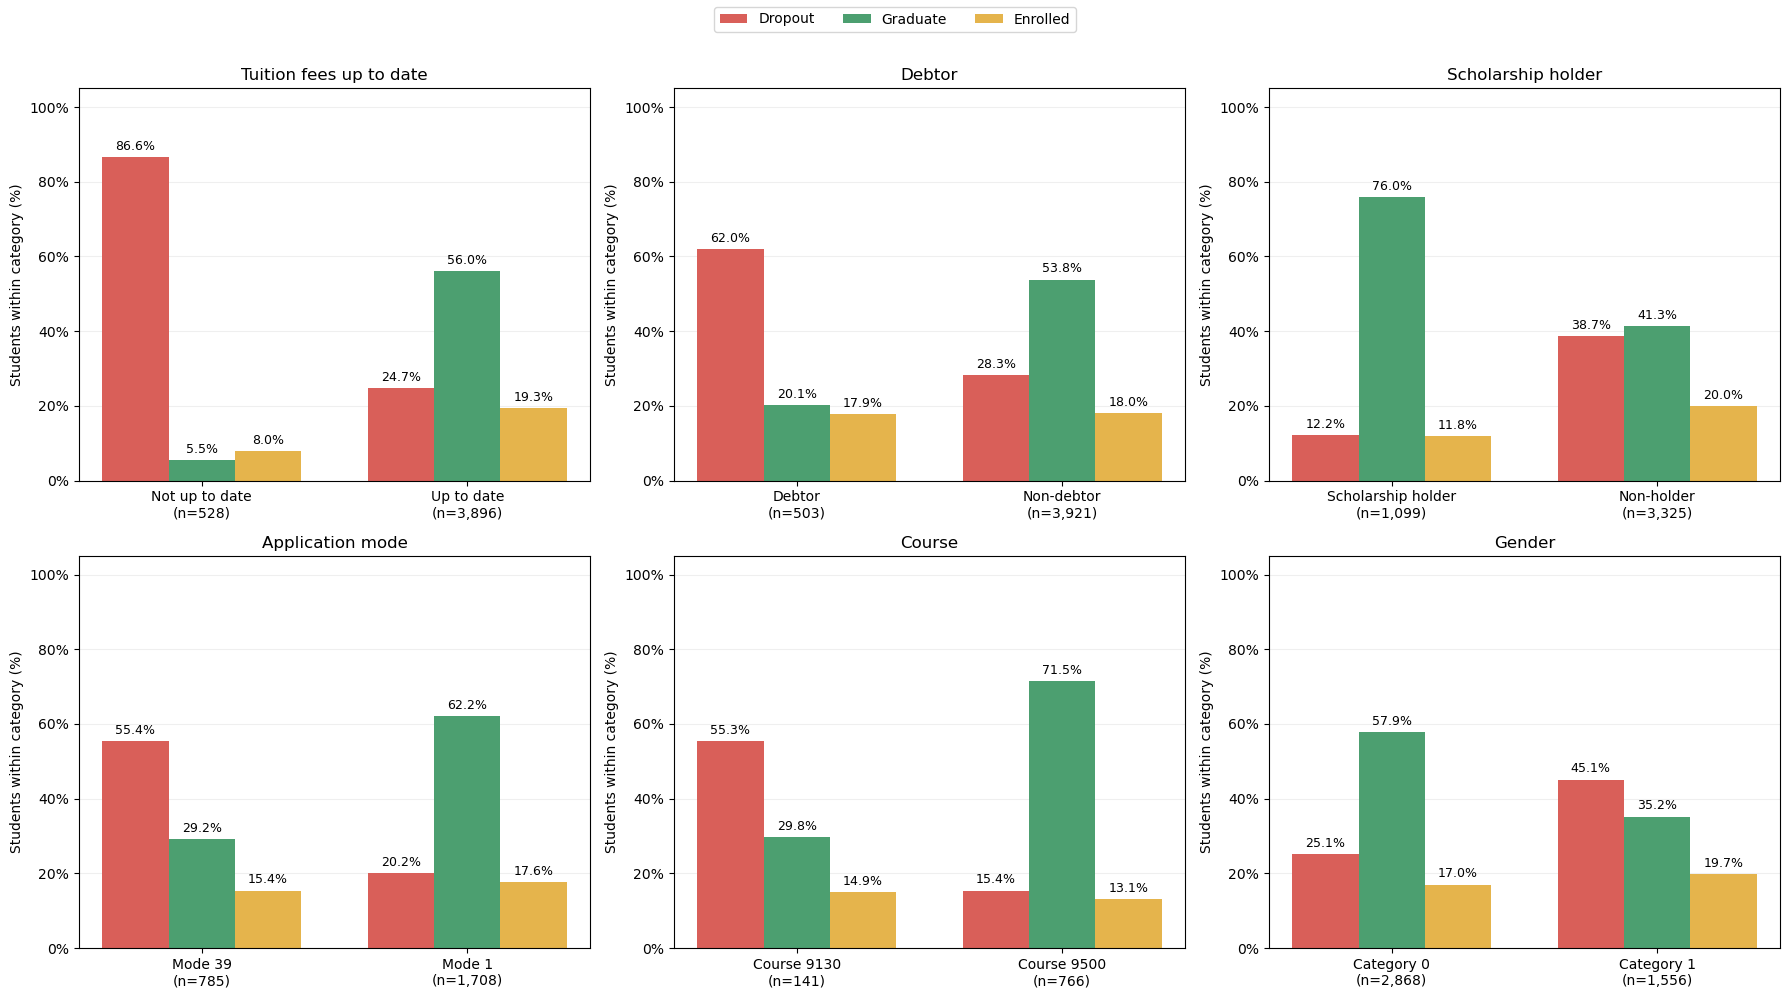

In [24]:
summary = pd.read_csv("category_outcome_summary.csv")
summary["Category"] = summary["Category"].astype(str)

comparisons = [
    ("Tuition fees up to date", ["0", "1"],
     ["Not up to date", "Up to date"]),
    ("Debtor", ["1", "0"],
     ["Debtor", "Non-debtor"]),
    ("Scholarship holder", ["1", "0"],
     ["Scholarship holder", "Non-holder"]),
    ("Application mode", ["39", "1"],
     ["Mode 39", "Mode 1"]),
    ("Course", ["9130", "9500"],
     ["Course 9130", "Course 9500"]),
    ("Gender", ["0", "1"],
     ["Category 0", "Category 1"]),
]

outcomes = ["Dropout", "Graduate", "Enrolled"]
colors = ["#d95f59", "#4c9f70", "#e5b44c"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
width = 0.25

for ax, (feature, categories, labels) in zip(axes.flat, comparisons):
    subset = (
        summary.loc[summary["Feature"] == feature]
        .set_index("Category")
        .loc[categories]
    )

    x = np.arange(len(categories))

    for i, (outcome, color) in enumerate(zip(outcomes, colors)):
        bars = ax.bar(
            x + (i - 1) * width,
            subset[f"{outcome} (%)"],
            width=width,
            label=outcome,
            color=color,
        )
        ax.bar_label(
            bars,
            labels=[f"{v:.1f}%" for v in subset[f"{outcome} (%)"]],
            padding=3,
            fontsize=9,
        )

    ax.set_xticks(x)
    ax.set_xticklabels([
        f"{label}\n(n={int(count):,})"
        for label, count in zip(labels, subset["Count"])
    ])
    ax.set_title(feature)
    ax.set_ylabel("Students within category (%)")
    ax.set_ylim(0, 105)
    ax.set_yticks(range(0, 101, 20))
    ax.yaxis.set_major_formatter(PercentFormatter(100))
    ax.set_axisbelow(True)
    ax.grid(axis="y", alpha=0.2)

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3)

fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(
    "clustered_outcome_comparisons.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

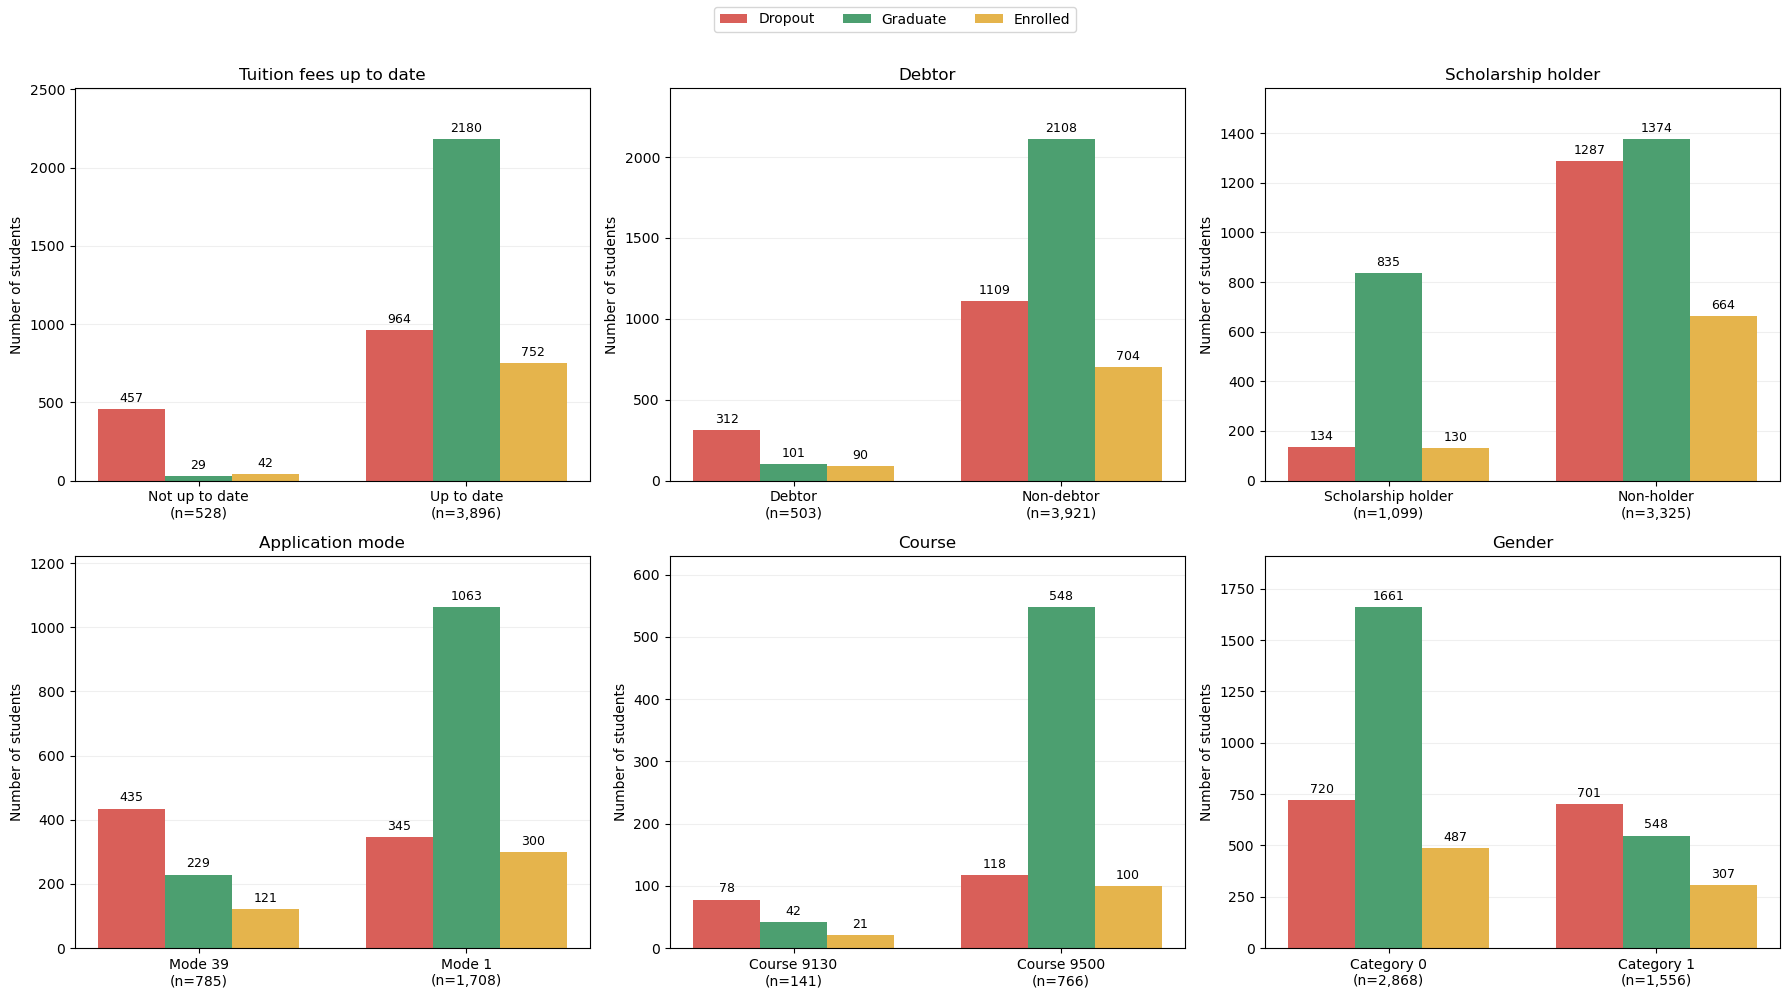

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

comparisons = [
    ("Tuition fees up to date", [0, 1],
     ["Not up to date", "Up to date"]),
    ("Debtor", [1, 0],
     ["Debtor", "Non-debtor"]),
    ("Scholarship holder", [1, 0],
     ["Scholarship holder", "Non-holder"]),
    ("Application mode", [39, 1],
     ["Mode 39", "Mode 1"]),
    ("Course", [9130, 9500],
     ["Course 9130", "Course 9500"]),
    ("Gender", [0, 1],
     ["Category 0", "Category 1"]),
]

outcomes = ["Dropout", "Graduate", "Enrolled"]
colors = ["#d95f59", "#4c9f70", "#e5b44c"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
width = 0.25

for ax, (feature, categories, labels) in zip(axes.flat, comparisons):
    counts = pd.crosstab(data[feature], data["Target"]).reindex(
        index=categories, columns=outcomes, fill_value=0
    )
    totals = counts.sum(axis=1)
    x = np.arange(len(categories))

    for i, (outcome, color) in enumerate(zip(outcomes, colors)):
        bars = ax.bar(
            x + (i - 1) * width,
            counts[outcome],
            width=width,
            label=outcome,
            color=color,
        )
        ax.bar_label(bars, fmt="%.0f", padding=3, fontsize=9)

    ax.set_xticks(x)
    ax.set_xticklabels([
        f"{label}\n(n={int(count):,})"
        for label, count in zip(labels, totals)
    ])
    ax.set_title(feature)
    ax.set_ylabel("Number of students")
    ax.margins(y=0.15)
    ax.set_axisbelow(True)
    ax.grid(axis="y", alpha=0.2)

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3)

fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(
    "clustered_outcome_counts.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

- Tuition fees: Students whose fees are not up to date have an 86.6% dropout rate, compared with 24.7% for those up to date. This is the largest observed gap, at 61.9 percentage points.
- Debtor status: Debtors have a higher dropout rate (62.0%) than non-debtors (28.3%), alongside a lower graduation rate (20.1% versus 53.8%).
- Scholarship: Scholarship holders have lower dropout (12.2% versus 38.7%) and higher graduation (76.0% versus 41.3%) than non-holders.
- Application mode: Students admitted through mode 39 have higher dropout (55.4%) than those admitted through mode 1 (20.2%), suggesting differences associated with admission pathways.
Course: Course 9130 has a higher dropout rate (55.3%) than course 9500 (15.4%). Graduation rates also differ considerably: 29.8% versus 71.5%.

### EDA for Numerical Features

This analysis examines the distributions, missing values, potential outliers,
and correlations of numerical features. It also compares their distributions
across Dropout, Graduate, and Enrolled students.

Potential outliers are flagged using the interquartile range (IQR) rule.
These observations are not automatically errors and will not be removed
without further investigation.

In [27]:
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

output_dir = Path("eda_numerical")
output_dir.mkdir(exist_ok=True)

# Zero-based positions for the original dataset column order.
num_indices = [6, 12, 19, *range(21, 36)]
num_cols = data.columns[num_indices].tolist()

# Work on a copy and preserve the original dataset.
numeric_data = data[num_cols].apply(pd.to_numeric, errors="raise")

outcomes = ["Dropout", "Graduate", "Enrolled"]
palette = {
    "Dropout": "#d95f59",
    "Graduate": "#4c9f70",
    "Enrolled": "#e5b44c",
}

print(f"Numerical features: {len(num_cols)}")
display(pd.DataFrame({"Numerical feature": num_cols}))

Numerical features: 18


,Numerical feature
0,Previous qualification (grade)
1,Admission grade
2,Age at enrollment
3,Curricular units 1st sem (credited)
4,Curricular units 1st sem (enrolled)
5,Curricular units 1st sem (evaluations)
6,Curricular units 1st sem (approved)
7,Curricular units 1st sem (grade)
8,Curricular units 1st sem (without evaluations)
9,Curricular units 2nd sem (credited)


#### Descriptive Statistics and Data Quality

The summary reports the number of available observations, missing values,
unique values, central tendency, spread, and skewness for each feature.

In [28]:
numerical_summary = numeric_data.describe().T.rename(
    columns={
        "count": "Non-missing count",
        "mean": "Mean",
        "std": "Standard deviation",
        "min": "Minimum",
        "25%": "Q1",
        "50%": "Median",
        "75%": "Q3",
        "max": "Maximum",
    }
)

numerical_summary["Missing count"] = numeric_data.isna().sum()
numerical_summary["Missing (%)"] = numeric_data.isna().mean() * 100
numerical_summary["Unique values"] = numeric_data.nunique()
numerical_summary["IQR"] = (
    numerical_summary["Q3"] - numerical_summary["Q1"]
)
numerical_summary["Skewness"] = numeric_data.skew()

with pd.option_context("display.max_columns", None):
    display(numerical_summary.round(2))

numerical_summary.to_csv(output_dir / "numerical_summary.csv")

,Non-missing count,Mean,Standard deviation,Minimum,Q1,Median,Q3,Maximum,Missing count,Missing (%),Unique values,IQR,Skewness
Previous qualification (grade),4424.0,132.61,13.19,95.00,125.00,133.10,140.00,190.00,0,0.0,101,15.00,0.31
Admission grade,4424.0,126.98,14.48,95.00,117.90,126.10,134.80,190.00,0,0.0,620,16.90,0.53
Age at enrollment,4424.0,23.27,7.59,17.00,19.00,20.00,25.00,70.00,0,0.0,46,6.00,2.05
Curricular units 1st sem (credited),4424.0,0.71,2.36,0.00,0.00,0.00,0.00,20.00,0,0.0,21,0.00,4.17
Curricular units 1st sem (enrolled),4424.0,6.27,2.48,0.00,5.00,6.00,7.00,26.00,0,0.0,23,2.00,1.62
Curricular units 1st sem (evaluations),4424.0,8.30,4.18,0.00,6.00,8.00,10.00,45.00,0,0.0,35,4.00,0.98
Curricular units 1st sem (approved),4424.0,4.71,3.09,0.00,3.00,5.00,6.00,26.00,0,0.0,23,3.00,0.77
Curricular units 1st sem (grade),4424.0,10.64,4.84,0.00,11.00,12.29,13.40,18.88,0,0.0,805,2.40,-1.57
Curricular units 1st sem (without evaluations),4424.0,0.14,0.69,0.00,0.00,0.00,0.00,12.00,0,0.0,11,0.00,8.21
Curricular units 2nd sem (credited),4424.0,0.54,1.92,0.00,0.00,0.00,0.00,19.00,0,0.0,19,0.00,4.63


#### Distribution of Numerical Features

Histograms show where values are concentrated and reveal asymmetry,
multiple peaks, and unusually large or small observations. Each feature
uses its own axis scale because the variables have different units.

Discrete counts may naturally show spikes. Zeros should be interpreted
using the variable definitions rather than assumed to represent missing data.

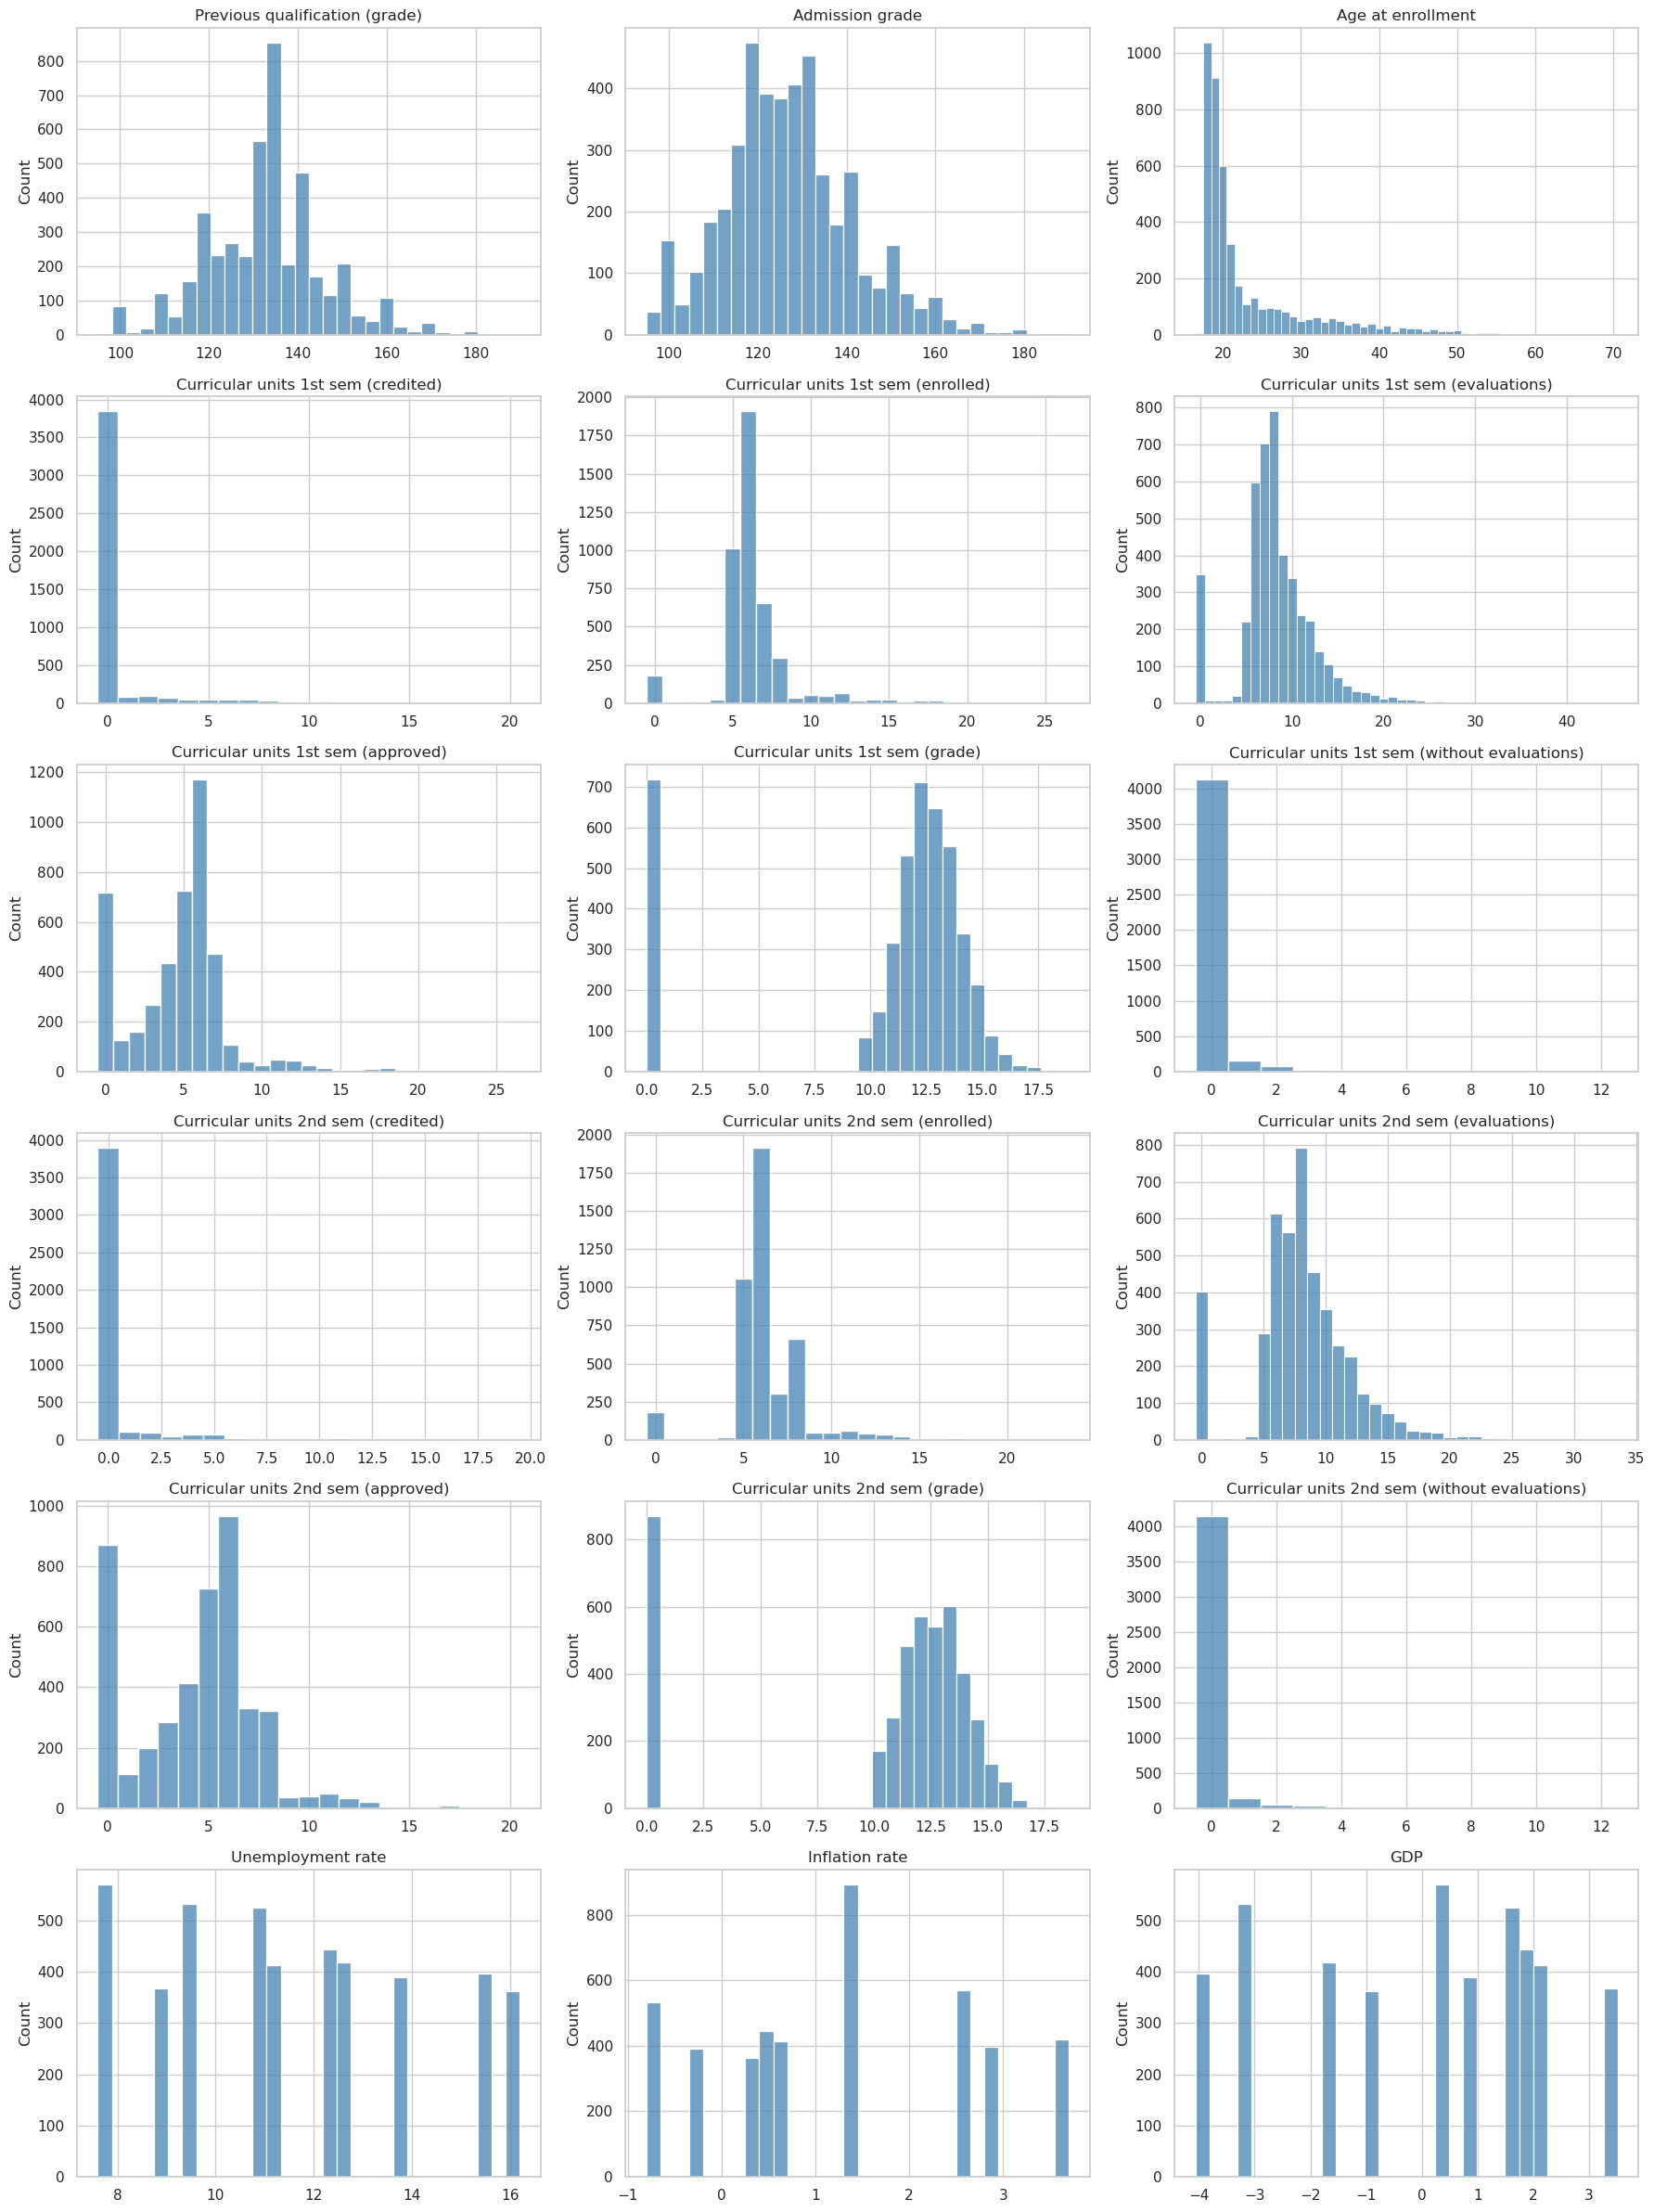

In [30]:
ncols = 3
nrows = math.ceil(len(num_cols) / ncols)

fig, axes = plt.subplots(
    nrows, ncols, figsize=(18, 4 * nrows), squeeze=False
)

for ax, col in zip(axes.flat, num_cols):
    values = numeric_data[col].dropna()

    # Use one bin per integer when the integer range is manageable.
    is_integer = (
        not values.empty
        and np.allclose(values, np.round(values))
    )

    if is_integer and values.max() - values.min() <= 60:
        bins = np.arange(values.min() - 0.5, values.max() + 1.5, 1)
    else:
        bins = 30

    sns.histplot(values, bins=bins, color="steelblue", ax=ax)
    ax.set_title(col, wrap=True)
    ax.set_xlabel("")
    ax.set_ylabel("Count")

for ax in axes.flat[len(num_cols):]:
    ax.set_visible(False)

fig.tight_layout()
fig.savefig(
    output_dir / "numerical_histograms.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

#### Potential Outliers

Values below Q1 − 1.5 × IQR or above Q3 + 1.5 × IQR are flagged as potential
outliers. Boxplots display these observations alongside the median and
middle 50% of values.

For count variables with many zeros or repeated values, the IQR rule can
flag valid observations. If the IQR is zero, the rule is particularly
limited and should be interpreted cautiously.

,Lower bound,Upper bound,Potential outlier count,Potential outlier (%),Zero IQR
Curricular units 2nd sem (grade),6.87,17.21,877,19.82,False
Curricular units 1st sem (grade),7.40,17.00,726,16.41,False
Curricular units 1st sem (credited),0.00,0.00,577,13.04,True
Curricular units 2nd sem (credited),0.00,0.00,530,11.98,True
Age at enrollment,10.00,34.00,441,9.97,False
Curricular units 1st sem (enrolled),2.00,10.00,424,9.58,False
Curricular units 2nd sem (enrolled),2.00,10.00,369,8.34,False
Curricular units 1st sem (without evaluations),0.00,0.00,294,6.65,True
Curricular units 2nd sem (without evaluations),0.00,0.00,282,6.37,True
Curricular units 1st sem (approved),-1.50,10.50,180,4.07,False


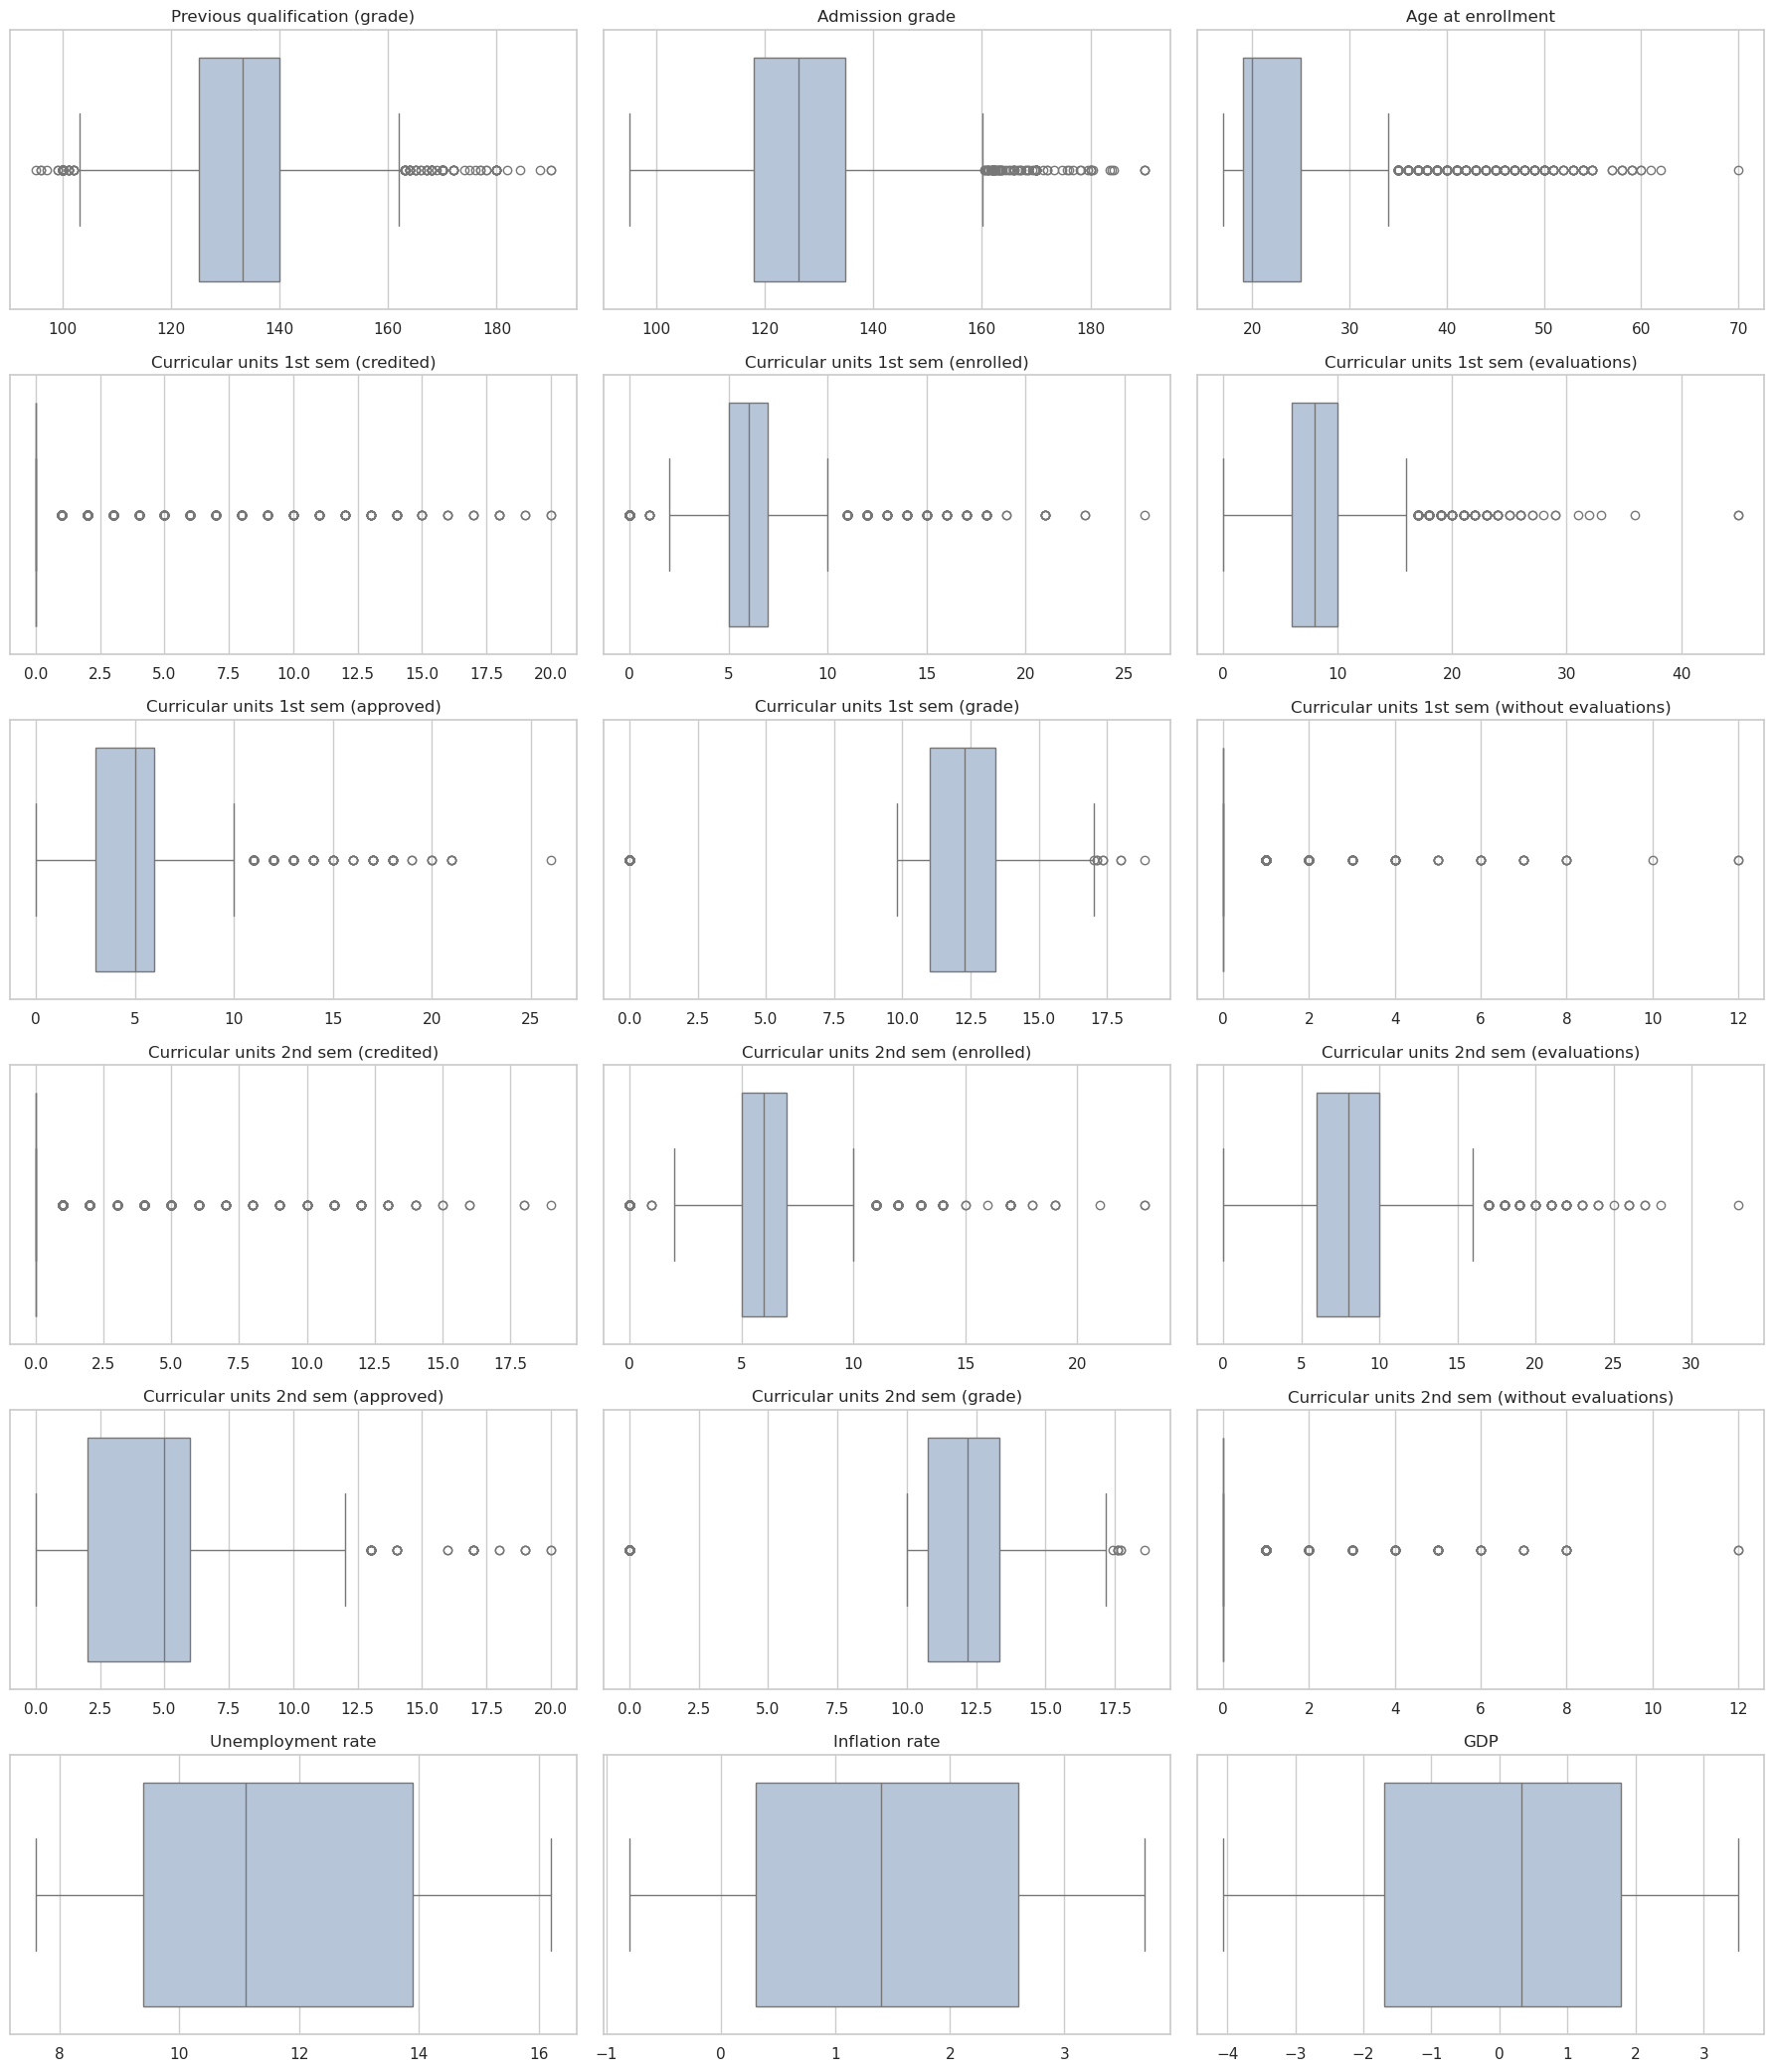

In [31]:
q1 = numeric_data.quantile(0.25)
q3 = numeric_data.quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outlier_mask = (
    numeric_data.lt(lower_bound, axis="columns")
    | numeric_data.gt(upper_bound, axis="columns")
)

outlier_summary = pd.DataFrame({
    "Lower bound": lower_bound,
    "Upper bound": upper_bound,
    "Potential outlier count": outlier_mask.sum(),
    "Potential outlier (%)": (
        outlier_mask.sum()
        .div(numeric_data.count().replace(0, np.nan))
        .mul(100)
    ),
    "Zero IQR": iqr.eq(0),
}).sort_values("Potential outlier (%)", ascending=False)

display(outlier_summary.round(2))
outlier_summary.to_csv(output_dir / "potential_outliers.csv")

fig, axes = plt.subplots(
    nrows, ncols, figsize=(18, 3.5 * nrows), squeeze=False
)

for ax, col in zip(axes.flat, num_cols):
    sns.boxplot(
        x=numeric_data[col],
        color="lightsteelblue",
        ax=ax,
    )
    ax.set_title(col, wrap=True)
    ax.set_xlabel("")

for ax in axes.flat[len(num_cols):]:
    ax.set_visible(False)

fig.tight_layout()
fig.savefig(
    output_dir / "numerical_boxplots.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

#### Numerical Features by Student Outcome

Boxplots compare the median, spread, and overlap of numerical features
across Dropout, Graduate, and Enrolled students. Differences may identify
features worth investigating further, but do not establish causation or
statistical significance.

The accompanying table reports sample sizes, means, medians, and quartiles
within each outcome group.

Count    Mean  \
Feature                                        Target                    
Previous qualification (grade)                 Dropout    1421  131.11   
                                               Graduate   2209  134.08   
                                               Enrolled    794  131.21   
Admission grade                                Dropout    1421  124.96   
                                               Graduate   2209  128.79   
                                               Enrolled    794  125.53   
Age at enrollment                              Dropout    1421   26.07   
                                               Graduate   2209   21.78   
                                               Enrolled    794   22.37   
Curricular units 1st sem (credited)            Dropout    1421    0.61   
                                               Graduate   2209    0.85   
                                               Enrolled    794    0.51   
Curricular units 1st sem (enrolled)            Dropout    1421    5.82   
                                               Graduate   2209    6.67   
                                               Enrolled    794    5.96   
Curricular units 1st sem (evaluations)         Dropout    1421    7.75   
                                               Graduate   2209    8.28   
                                               Enrolled    794    9.34   
Curricular units 1st sem (approved)            Dropout    1421    2.55   
                                               Graduate   2209    6.23   
                                               Enrolled    794    4.32   
Curricular units 1st sem (grade)               Dropout    1421    7.26   
                                               Graduate   2209   12.64   
                                               Enrolled    794   11.13   
Curricular units 1st sem (without evaluations) Dropout    1421    0.19   
                                               Graduate   2209    0.09   
                                               Enrolled    794    0.18   
Curricular units 2nd sem (credited)            Dropout    1421    0.45   
                                               Graduate   2209    0.67   
                                               Enrolled    794    0.36   
Curricular units 2nd sem (enrolled)            Dropout    1421    5.78   
                                               Graduate   2209    6.63   
                                               Enrolled    794    5.94   
Curricular units 2nd sem (evaluations)         Dropout    1421    7.17   
                                               Graduate   2209    8.14   
                                               Enrolled    794    9.44   
Curricular units 2nd sem (approved)            Dropout    1421    1.94   
                                               Graduate   2209    6.18   
                                               Enrolled    794    4.06   
Curricular units 2nd sem (grade)               Dropout    1421    5.90   
                                               Graduate   2209   12.70   
                                               Enrolled    794   11.12   
Curricular units 2nd sem (without evaluations) Dropout    1421    0.24   
                                               Graduate   2209    0.08   
                                               Enrolled    794    0.19   
Unemployment rate                              Dropout    1421   11.62   
                                               Graduate   2209   11.64   
                                               Enrolled    794   11.27   
Inflation rate                                 Dropout    1421    1.28   
                                               Graduate   2209    1.20   
                                               Enrolled    794    1.21   
GDP                                            Dropout    1421   -0.15   
                                               Graduate   220

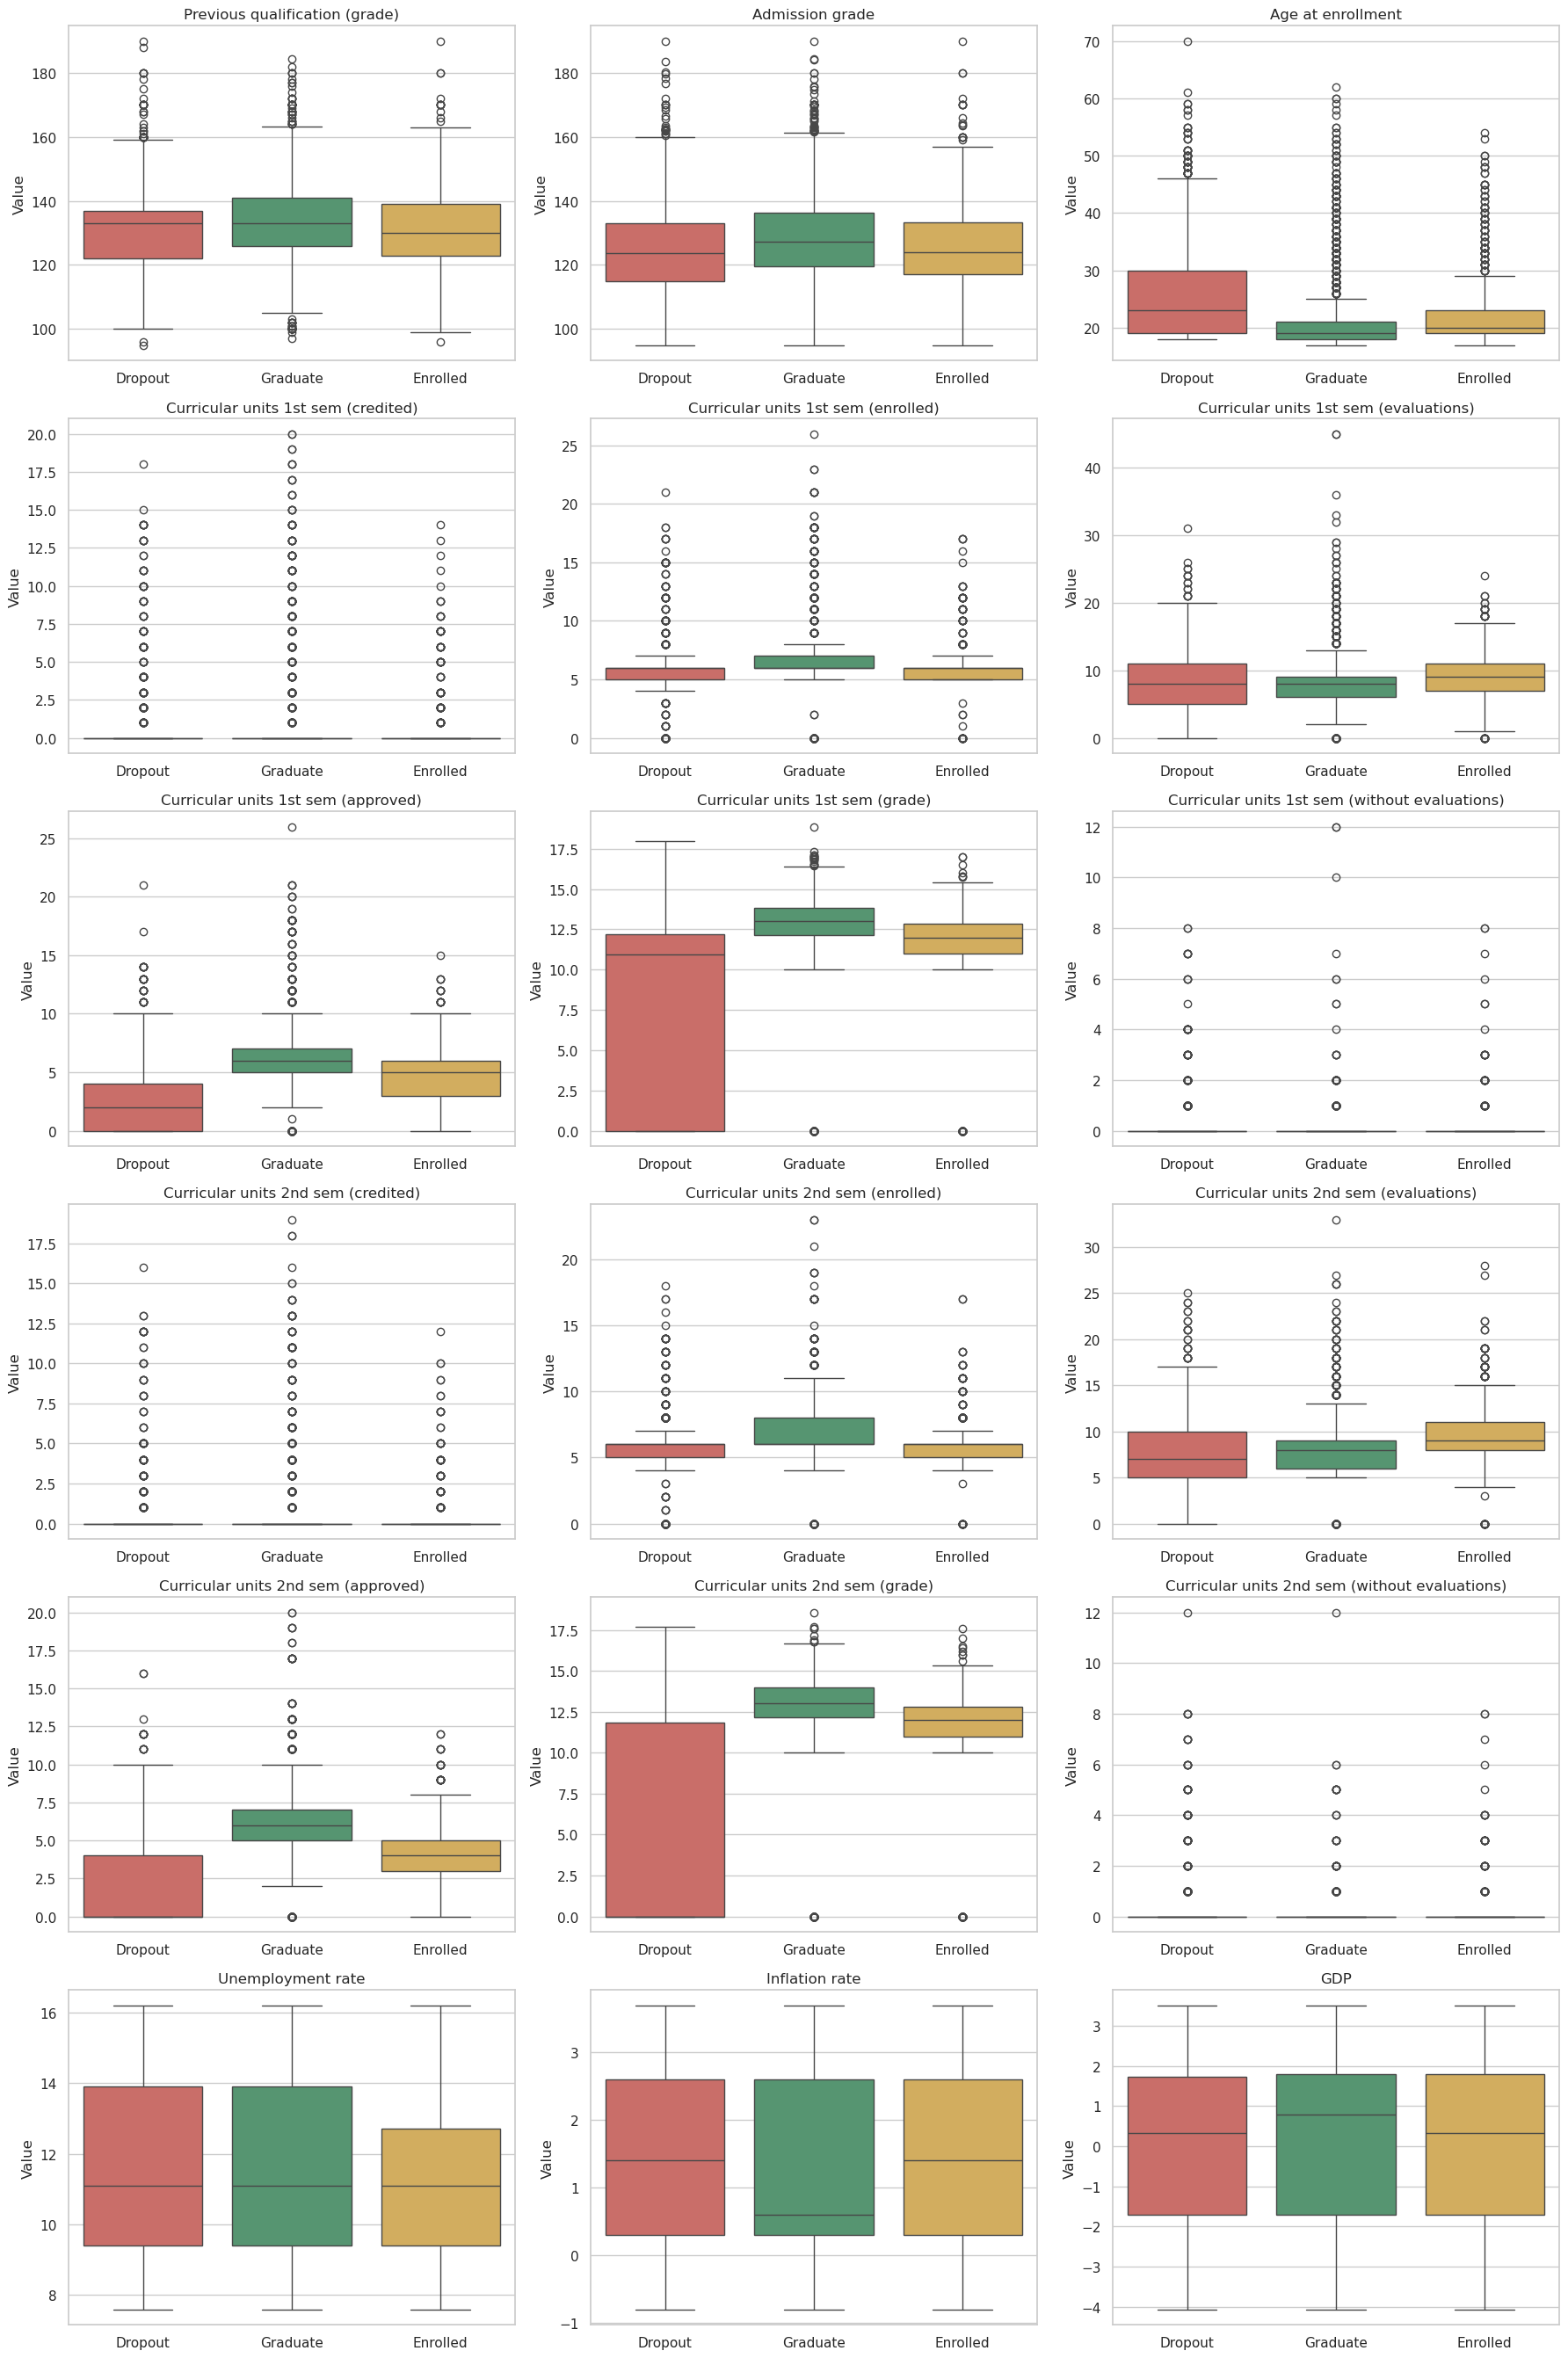

In [32]:
plot_data = numeric_data.copy()
plot_data["Target"] = data["Target"]

long_data = plot_data.melt(
    id_vars="Target",
    value_vars=num_cols,
    var_name="Feature",
    value_name="Value",
)

outcome_summary = (
    long_data.groupby(["Feature", "Target"], observed=True)["Value"]
    .agg(
        Count="count",
        Mean="mean",
        Median="median",
        Q1=lambda values: values.quantile(0.25),
        Q3=lambda values: values.quantile(0.75),
    )
    .reindex(pd.MultiIndex.from_product(
        [num_cols, outcomes],
        names=["Feature", "Target"],
    ))
)

with pd.option_context("display.max_rows", None):
    display(outcome_summary.round(2))

outcome_summary.to_csv(output_dir / "numerical_summary_by_target.csv")

fig, axes = plt.subplots(
    nrows, ncols, figsize=(18, 4.5 * nrows), squeeze=False
)

for ax, col in zip(axes.flat, num_cols):
    sns.boxplot(
        data=plot_data,
        x="Target",
        y=col,
        order=outcomes,
        hue="Target",
        hue_order=outcomes,
        palette=palette,
        dodge=False,
        ax=ax,
    )

    if ax.get_legend() is not None:
        ax.get_legend().remove()

    ax.set_title(col, wrap=True)
    ax.set_xlabel("")
    ax.set_ylabel("Value")

for ax in axes.flat[len(num_cols):]:
    ax.set_visible(False)

fig.tight_layout()
fig.savefig(
    output_dir / "numerical_features_by_target.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

#### Correlations Between Numerical Features

Spearman correlation measures the strength and direction of monotonic
relationships between numerical features. It is useful for this dataset
because numerical features include counts and potentially skewed distributions.

Strong correlations may indicate overlapping information, particularly
between related first- and second-semester measures. Correlation does not
establish causation. The categorical Target is excluded rather than assigned
arbitrary numerical codes.

,ID,Feature
0,N1,Previous qualification (grade)
1,N2,Admission grade
2,N3,Age at enrollment
3,N4,Curricular units 1st sem (credited)
4,N5,Curricular units 1st sem (enrolled)
5,N6,Curricular units 1st sem (evaluations)
6,N7,Curricular units 1st sem (approved)
7,N8,Curricular units 1st sem (grade)
8,N9,Curricular units 1st sem (without evaluations)
9,N10,Curricular units 2nd sem (credited)


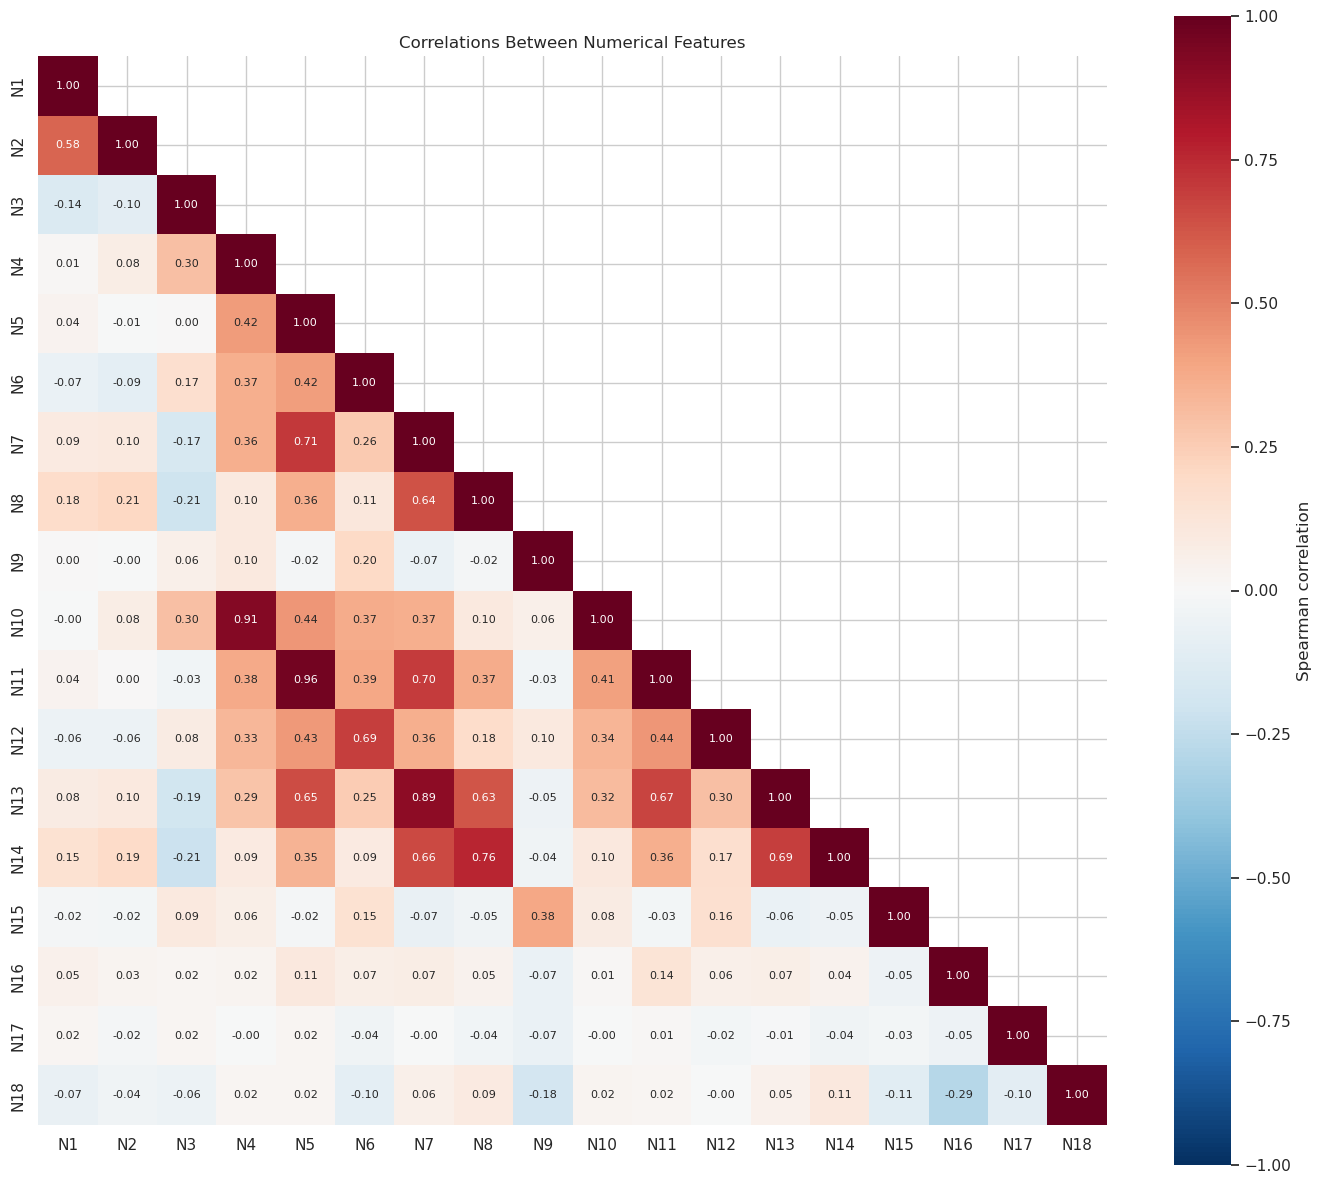

,Feature 1,Feature 2,Spearman correlation,Absolute correlation
67,Curricular units 1st sem (enrolled),Curricular units 2nd sem (enrolled),0.962,0.962
53,Curricular units 1st sem (credited),Curricular units 2nd sem (credited),0.914,0.914
92,Curricular units 1st sem (approved),Curricular units 2nd sem (approved),0.892,0.892
103,Curricular units 1st sem (grade),Curricular units 2nd sem (grade),0.762,0.762
63,Curricular units 1st sem (enrolled),Curricular units 1st sem (approved),0.707,0.707
90,Curricular units 1st sem (approved),Curricular units 2nd sem (enrolled),0.699,0.699
138,Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),0.694,0.694
80,Curricular units 1st sem (evaluations),Curricular units 2nd sem (evaluations),0.694,0.694
126,Curricular units 2nd sem (enrolled),Curricular units 2nd sem (approved),0.674,0.674
93,Curricular units 1st sem (approved),Curricular units 2nd sem (grade),0.663,0.663


In [33]:
correlation = numeric_data.corr(method="spearman")

# Short labels keep the heatmap readable.
feature_ids = [f"N{i + 1}" for i in range(len(num_cols))]
feature_key = pd.DataFrame({
    "ID": feature_ids,
    "Feature": num_cols,
})
display(feature_key)

heatmap_data = correlation.copy()
heatmap_data.index = feature_ids
heatmap_data.columns = feature_ids

mask = np.triu(
    np.ones_like(heatmap_data, dtype=bool),
    k=1,
)

fig, ax = plt.subplots(figsize=(14, 12))

sns.heatmap(
    heatmap_data,
    mask=mask,
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    center=0,
    annot=True,
    fmt=".2f",
    annot_kws={"fontsize": 8},
    square=True,
    cbar_kws={"label": "Spearman correlation"},
    ax=ax,
)

ax.set_title("Correlations Between Numerical Features")
fig.tight_layout()
fig.savefig(
    output_dir / "numerical_correlations.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

# Unique feature pairs, excluding self-correlations.
upper_triangle = np.triu(
    np.ones(correlation.shape, dtype=bool),
    k=1,
)

correlation_pairs = (
    correlation.where(upper_triangle)
    .stack()
    .rename("Spearman correlation")
    .reset_index()
)
correlation_pairs.columns = [
    "Feature 1", "Feature 2", "Spearman correlation"
]
correlation_pairs["Absolute correlation"] = (
    correlation_pairs["Spearman correlation"].abs()
)
correlation_pairs = correlation_pairs.sort_values(
    "Absolute correlation",
    ascending=False,
)

display(correlation_pairs.head(15).round(3))

correlation.to_csv(output_dir / "spearman_correlations.csv")
correlation_pairs.to_csv(
    output_dir / "correlation_pairs.csv", index=False
)
feature_key.to_csv(output_dir / "correlation_feature_key.csv", index=False)

### EDA Interpretation

The numerical EDA shows that semester grades and approved curricular units provide the clearest separation between outcomes. Age also differs across groups, while entry grades and economic indicators show more overlap. These findings identify promising predictors, but model validation is still needed to establish their predictive value.

**1. Academic performance differs substantially across outcomes**

The group medians make these differences clear:

| Numerical feature | Dropout | Graduate | Enrolled |
|---|---:|---:|---:|
| First-semester approved units | 2 | 6 | 5 |
| Second-semester approved units | 0 | 6 | 4 |
| First-semester grade | 10.93 | 13.00 | 12.00 |
| Second-semester grade | 0.00 | 13.00 | 12.00 |
| Age at enrollment | 23 | 19 | 20 |
| Admission grade | 123.6 | 127.4 | 124.1 |
| Previous qualification grade | 133.1 | 133.1 | 130.0 |

Graduates typically approve more units and achieve higher semester grades. Dropout students have particularly low second-semester results: both their median grade and median approved-unit count are zero.

Enrolled students generally fall between the other groups, with considerable overlap. This suggests that Enrolled may be harder to distinguish, although only model evaluation can confirm that.


Entry grades show smaller differences. For example, Dropout and Graduate students have identical median previous-qualification grades despite different means. These features may still contribute when combined with others.
</div>

**2. Most numerical distributions are not symmetric**

Age is right-skewed: the overall median is 20, the mean is 23.27, and ages range from 17 to 70. Older students should not be removed simply because they lie beyond the boxplot whiskers.
    
Credited units and units without evaluations are heavily concentrated at zero. Semester grades have a separate concentration at zero alongside nonzero grades around 12–14. This means their means combine two different parts of the distribution.

**3. Several semester features contain overlapping information**

| First- versus second-semester measure | Spearman correlation |
|---|---:|
| Enrolled units | 0.962 |
| Credited units | 0.914 |
| Approved units | 0.892 |
| Grade | 0.762 |
| Evaluations | 0.694 |


These correlations indicate substantial redundancy, particularly for enrolled and credited units. 

**4. Economic indicators show limited outcome separation**

Unemployment has the same median, 11.1, across all three outcomes. Inflation and GDP differ somewhat, but their distributions overlap substantially.


### Preprocessing and Feature Engineering

The dataset is divided into stratified training, validation, and test sets
using a 60:20:20 split. Learned preprocessing parameters and feature selection
are fitted on training data only. The validation set supports exploratory
evaluation, while the test set is reserved for final model assessment.

All original predictors are initially retained. Target is encoded separately.
Because semester results are included, this analysis assumes prediction after
second-semester information becomes available. The timing of other variables,
including payment status, must also be verified.

Earlier EDA examined the full dataset. This is acknowledged as a limitation;
subsequent model decisions will avoid using test-set results.

In [35]:
from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    LabelEncoder, OneHotEncoder, StandardScaler, FunctionTransformer
)
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.inspection import permutation_importance
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, f1_score

In [36]:
SEED = 42
output_dir = Path("preprocessing_outputs")
output_dir.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid")

df = data.copy()
df.columns = df.columns.str.strip()

if df.columns.duplicated().any():
    raise ValueError("Duplicate column names found after stripping whitespace.")

if df["Target"].isna().any():
    raise ValueError("Missing Target values must be investigated first.")

df["Target"] = df["Target"].astype(str).str.strip()

expected_targets = {"Dropout", "Graduate", "Enrolled"}
if set(df["Target"]) != expected_targets:
    raise ValueError("Unexpected Target labels.")

# Explicit names avoid dependence on column positions.
num_cols = [
    "Previous qualification (grade)",
    "Admission grade",
    "Age at enrollment",
    *[
        f"Curricular units {semester} sem ({measure})"
        for semester in ["1st", "2nd"]
        for measure in [
            "credited", "enrolled", "evaluations",
            "approved", "grade", "without evaluations"
        ]
    ],
    "Unemployment rate",
    "Inflation rate",
    "GDP",
]

missing_columns = set(num_cols) - set(df.columns)
if missing_columns:
    raise ValueError(f"Missing expected columns: {missing_columns}")

categ_cols = [
    col for col in df.columns
    if col not in num_cols + ["Target"]
]

df[num_cols] = df[num_cols].apply(pd.to_numeric, errors="raise")

if np.isinf(df[num_cols].to_numpy(dtype=float)).any():
    raise ValueError("Infinite numerical values found.")

print("Original numerical features:", len(num_cols))
print("Original categorical features:", len(categ_cols))
print("Exact duplicate rows:", df.duplicated().sum())
# Do not automatically delete identical rows: they may be different students.

X = df.drop(columns="Target")
y = df["Target"]

X_train, X_remaining, y_train_text, y_remaining = train_test_split(
    X, y,
    test_size=0.40,
    stratify=y,
    random_state=SEED,
)

X_valid, X_test, y_valid_text, y_test_text = train_test_split(
    X_remaining, y_remaining,
    test_size=0.50,
    stratify=y_remaining,
    random_state=SEED,
)

target_encoder = LabelEncoder()
y_train = target_encoder.fit_transform(y_train_text)
y_valid = target_encoder.transform(y_valid_text)
y_test = target_encoder.transform(y_test_text)

display(pd.DataFrame({
    "Target": target_encoder.classes_,
    "Encoded label": target_encoder.transform(target_encoder.classes_),
}))

split_summary = pd.DataFrame({
    "Training": y_train_text.value_counts(),
    "Validation": y_valid_text.value_counts(),
    "Test": y_test_text.value_counts(),
}).reindex(["Dropout", "Graduate", "Enrolled"])

display(split_summary)

Original numerical features: 18
Original categorical features: 18
Exact duplicate rows: 0


,Target,Encoded label
0,Dropout,0
1,Enrolled,1
2,Graduate,2


,Training,Validation,Test
Target,,,
Dropout,853,284,284
Graduate,1325,442,442
Enrolled,476,159,159


### Domain-Derived Features and Binning

Additional features describe academic progress:

- Approved units divided by enrolled units within each semester.
- Units without evaluations divided by enrolled units.
- Indicators of zero approved units and zero enrolled units.
- Changes in grades and approved units between semesters.
- Age groups using fixed, interpretable boundaries.

The original numerical variables remain available alongside these features.
Undefined ratios are represented as missing values, not as zero. A separate
indicator records zero enrollment.

Zero grades and other valid extreme observations are retained. The IQR rule
alone does not justify their removal.

In [38]:
ratio_cols = [
    "Approval ratio 1st sem",
    "Approval ratio 2nd sem",
    "Without evaluation ratio 1st sem",
    "Without evaluation ratio 2nd sem",
]

derived_num_cols = ratio_cols + [
    "Grade change",
    "Approved units change",
]

derived_cat_cols = [
    "Age group",
    "Zero approved 1st sem",
    "Zero approved 2nd sem",
    "Zero enrolled 1st sem",
    "Zero enrolled 2nd sem",
]

all_num_cols = num_cols + derived_num_cols
all_cat_cols = categ_cols + derived_cat_cols


from student_dropout.features import engineer_features


X_train_engineered = engineer_features(X_train)

display(X_train_engineered[derived_num_cols + derived_cat_cols].head())

# Investigate ratios above one; do not silently clip them.
ratio_checks = pd.DataFrame({
    "Undefined count": X_train_engineered[ratio_cols].isna().sum(),
    "Below zero count": X_train_engineered[ratio_cols].lt(0).sum(),
    "Above one count": X_train_engineered[ratio_cols].gt(1).sum(),
})

display(ratio_checks)

,Approval ratio 1st sem,Approval ratio 2nd sem,Without evaluation ratio 1st sem,Without evaluation ratio 2nd sem,Grade change,Approved units change,Age group,Zero approved 1st sem,Zero approved 2nd sem,Zero enrolled 1st sem,Zero enrolled 2nd sem
3207,1.000000,1.000000,0.0,0.0,0.0,0,25–34,0.0,0.0,0.0,0.0
3731,0.416667,0.333333,0.0,0.0,0.3,-1,20–24,0.0,0.0,0.0,0.0
884,0.875000,0.875000,0.0,0.0,0.0,0,Under 20,0.0,0.0,0.0,0.0
1394,0.833333,1.000000,0.0,0.0,0.9,1,Under 20,0.0,0.0,0.0,0.0
2659,1.000000,0.833333,0.0,0.0,1.2,-1,Under 20,0.0,0.0,0.0,0.0


,Undefined count,Below zero count,Above one count
Approval ratio 1st sem,122,0,0
Approval ratio 2nd sem,122,0,0
Without evaluation ratio 1st sem,122,0,0
Without evaluation ratio 2nd sem,122,0,1


### Applied EDA of Engineered Features

Training-set distributions and outcome comparisons are examined for the
engineered numerical features. Age-group outcome percentages are interpreted
alongside sample sizes.

These analyses describe associations rather than causal effects.
Clustering is not required because the task is supervised classification.

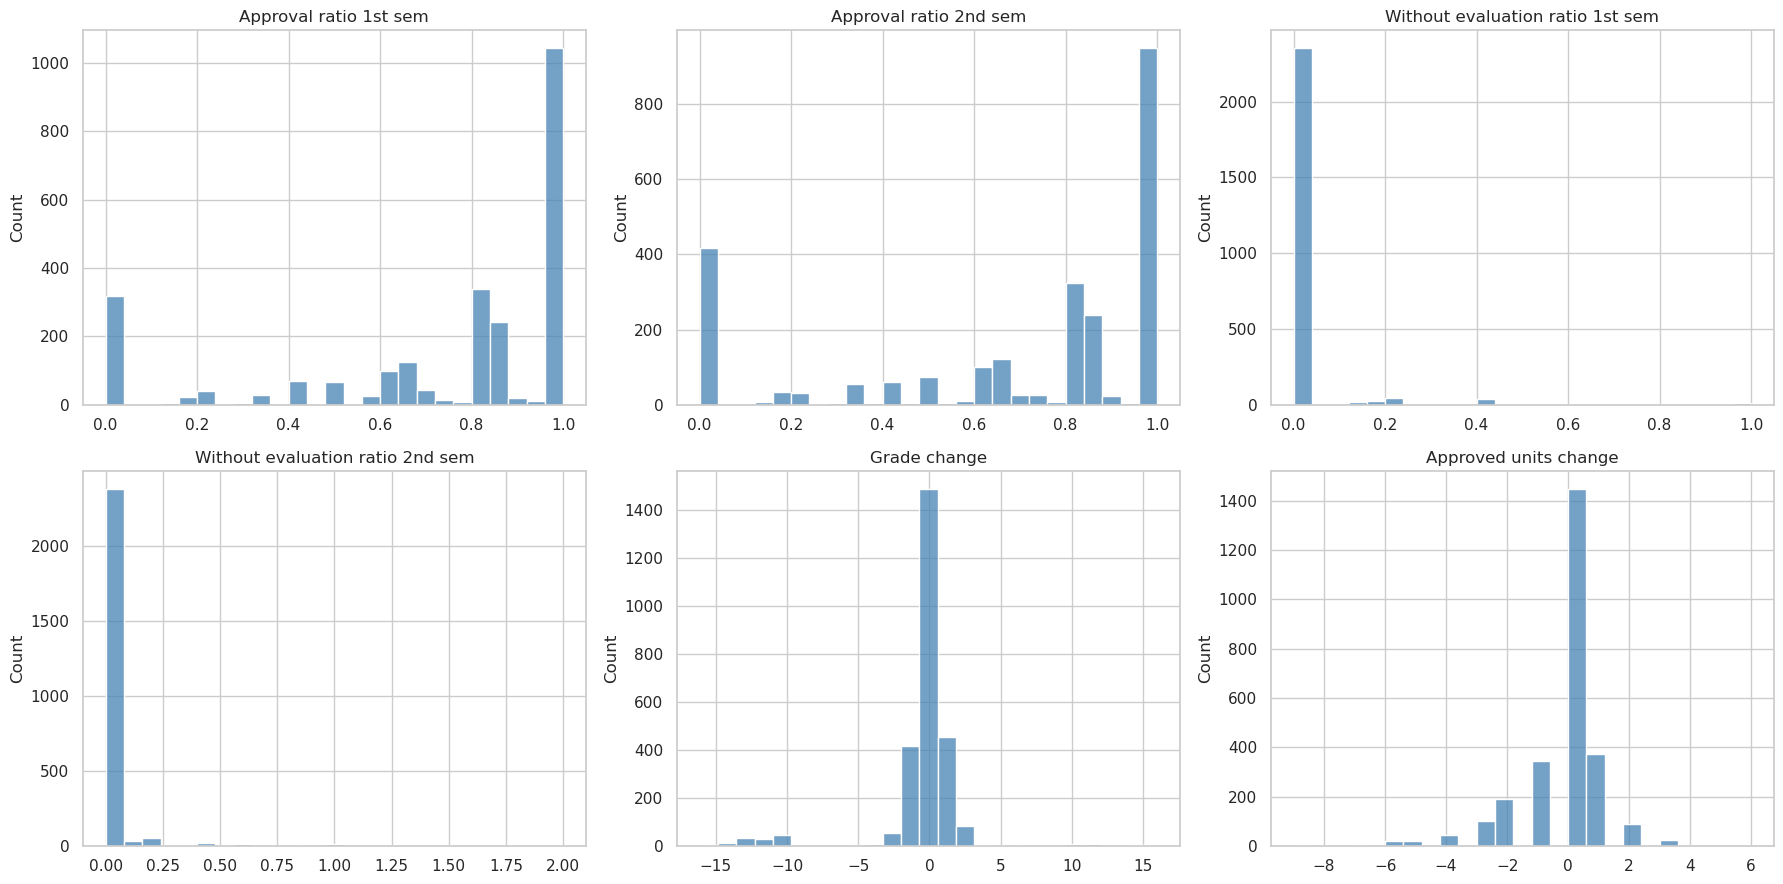

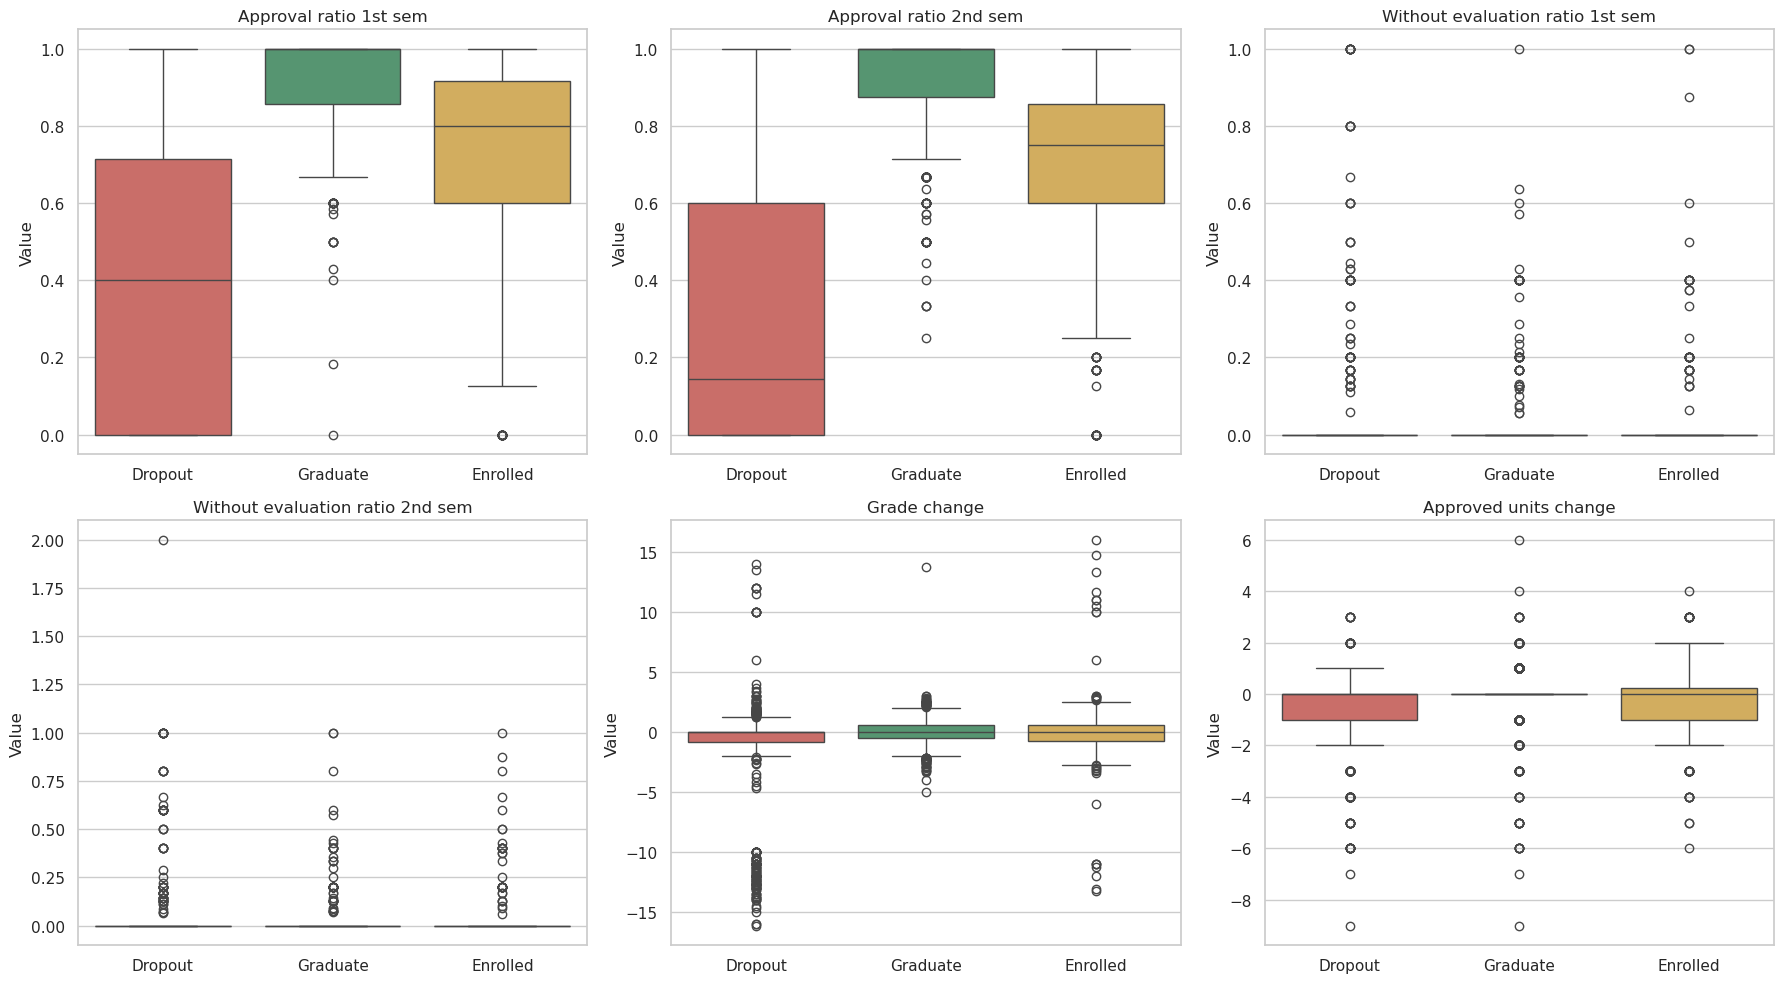

,Count,Dropout (%),Graduate (%),Enrolled (%)
Age group,,,,
Under 20,1199,21.7,61.4,16.9
20–24,774,28.4,49.5,22.1
25–34,407,55.0,27.3,17.7
35+,274,54.4,34.7,10.9


In [40]:
outcomes = ["Dropout", "Graduate", "Enrolled"]
palette = {
    "Dropout": "#d95f59",
    "Graduate": "#4c9f70",
    "Enrolled": "#e5b44c",
}

eda_train = X_train_engineered.copy()
eda_train["Target"] = y_train_text.to_numpy()

# Distributions of the six engineered numerical features.
fig, axes = plt.subplots(2, 3, figsize=(18, 9))

for ax, col in zip(axes.flat, derived_num_cols):
    sns.histplot(
        data=eda_train, x=col,
        bins=25, color="steelblue", ax=ax
    )
    ax.set_title(col)
    ax.set_xlabel("")

fig.tight_layout()
fig.savefig(
    output_dir / "engineered_distributions.png",
    dpi=300, bbox_inches="tight"
)
plt.show()

# Relationships with Target.
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, col in zip(axes.flat, derived_num_cols):
    sns.boxplot(
        data=eda_train,
        x="Target", y=col,
        order=outcomes,
        hue="Target", hue_order=outcomes,
        palette=palette,
        dodge=False,
        ax=ax,
    )
    if ax.get_legend() is not None:
        ax.get_legend().remove()

    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Value")

fig.tight_layout()
fig.savefig(
    output_dir / "engineered_features_by_target.png",
    dpi=300, bbox_inches="tight"
)
plt.show()

age_counts = pd.crosstab(
    eda_train["Age group"], eda_train["Target"]
).reindex(
    index=["Under 20", "20–24", "25–34", "35+"],
    columns=outcomes,
    fill_value=0,
)

age_summary = age_counts.div(
    age_counts.sum(axis=1).replace(0, np.nan), axis=0
).mul(100).round(1)

age_summary.columns = [f"{col} (%)" for col in age_summary.columns]
age_summary.insert(0, "Count", age_counts.sum(axis=1))

display(age_summary)
age_summary.to_csv(output_dir / "training_age_group_summary.csv")

### Preprocessing Pipeline

Numerical predictors are median-imputed and standardized; categorical predictors are imputed and one-hot encoded, grouping rare levels using training frequencies. Explicit zero-enrollment indicators describe undefined ratios; redundant automatic missing indicators are disabled. Each fitted transformation, feature selector, and PCA is refitted inside each training cross-validation fold. Target is encoded separately and never included among predictors.


In [52]:
numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median",
            add_indicator=False,  # Explicit zero-enrollment indicators remain.
            keep_empty_features=True,
        ),
    ),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="constant",
            fill_value="Missing",
            keep_empty_features=True,
        ),
    ),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="infrequent_if_exist",
            min_frequency=10,
            sparse_output=False,
        ),
    ),
])

# Retain all original and engineered features.
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, all_num_cols),
        ("cat", categorical_pipeline, all_cat_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=True,
)

# Unfitted template for later cross-validation.
preparation_template = Pipeline([
    (
        "engineer",
        FunctionTransformer(engineer_features, validate=False),
    ),
    ("preprocess", preprocessor),
])

# Fit only on training data.
preparation = clone(preparation_template)

X_train_prepared = preparation.fit_transform(X_train)
X_valid_prepared = preparation.transform(X_valid)
X_test_prepared = preparation.transform(X_test)

feature_names = preparation.named_steps[
    "preprocess"
].get_feature_names_out()

assert np.isfinite(X_train_prepared).all()
assert np.isfinite(X_valid_prepared).all()
assert np.isfinite(X_test_prepared).all()

print("Training:", X_train_prepared.shape)
print("Validation:", X_valid_prepared.shape)
print("Test:", X_test_prepared.shape)

display(pd.DataFrame(
    X_train_prepared[:5],
    columns=feature_names,
))

Training: (2654, 159)
Validation: (885, 159)
Test: (885, 159)


,num__Previous qualification (grade),num__Admission grade,num__Age at enrollment,num__Curricular units 1st sem (credited),num__Curricular units 1st sem (enrolled),num__Curricular units 1st sem (evaluations),num__Curricular units 1st sem (approved),num__Curricular units 1st sem (grade),num__Curricular units 1st sem (without evaluations),num__Curricular units 2nd sem (credited),...,cat__Age group_35+,cat__Age group_Under 20,cat__Zero approved 1st sem_0.0,cat__Zero approved 1st sem_1.0,cat__Zero approved 2nd sem_0.0,cat__Zero approved 2nd sem_1.0,cat__Zero enrolled 1st sem_0.0,cat__Zero enrolled 1st sem_1.0,cat__Zero enrolled 2nd sem_0.0,cat__Zero enrolled 2nd sem_1.0
0,-1.803036,-1.050003,0.224522,-0.305532,-0.100882,-0.047509,0.409767,0.195161,-0.209627,-0.286892,...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1,-0.821940,0.121705,-0.296695,1.338427,2.244288,1.151044,0.089625,0.528226,-0.209627,1.768200,...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
2,-0.444596,-0.553750,-0.557303,-0.305532,0.680841,0.911333,0.729909,0.405518,-0.209627,-0.286892,...,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
3,-1.501161,-1.160281,-0.557303,-0.305532,-0.100882,-0.526930,0.089625,0.201004,-0.209627,-0.286892,...,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
4,-0.595533,-0.209130,-0.557303,-0.305532,-0.100882,-0.287219,0.409767,0.078296,-0.209627,-0.286892,...,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0


### Exploratory Feature Importance

An exploratory random forest is fitted on training data to support the
rubric's model-based explainability requirement. This is not the final model.

Permutation importance measures the decrease in validation macro F1 when
an original feature is shuffled. Feature engineering is recomputed after
shuffling, so an original variable and its derived effects are evaluated
together.

Positive importance indicates that shuffling reduced performance.
Near-zero or negative values do not prove irrelevance, particularly when
predictors are correlated. Importance describes the fitted model and is
not a causal effect.

Exploratory validation macro F1: 0.725
              precision    recall  f1-score   support

     Dropout       0.83      0.74      0.78       284
    Enrolled       0.51      0.55      0.53       159
    Graduate       0.84      0.88      0.86       442

    accuracy                           0.78       885
   macro avg       0.73      0.72      0.72       885
weighted avg       0.78      0.78      0.78       885



,Feature,Importance,Repeat SD
30,Curricular units 2nd sem (approved),0.174586,0.011322
24,Curricular units 1st sem (approved),0.046092,0.007316
16,Tuition fees up to date,0.034522,0.009874
31,Curricular units 2nd sem (grade),0.014439,0.007835
18,Scholarship holder,0.008728,0.004556
28,Curricular units 2nd sem (enrolled),0.007348,0.005285
19,Age at enrollment,0.006656,0.006302
33,Unemployment rate,0.006595,0.002532
23,Curricular units 1st sem (evaluations),0.006518,0.004840
29,Curricular units 2nd sem (evaluations),0.005786,0.001802


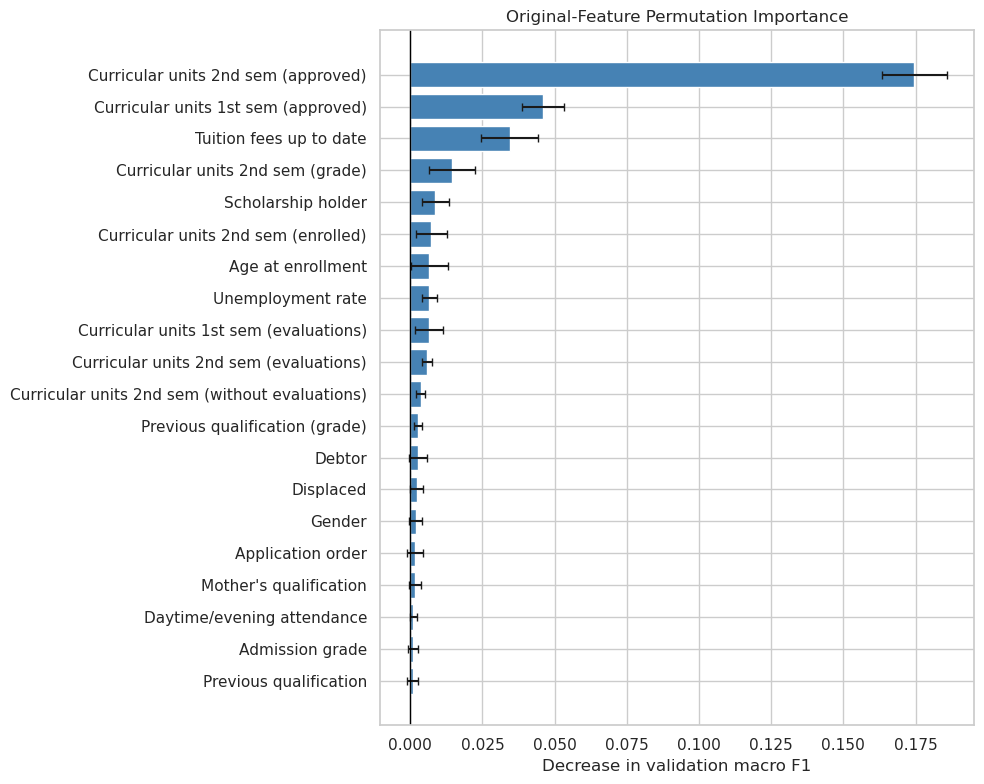

In [53]:
exploratory_forest = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=3,
    class_weight="balanced",
    random_state=SEED,
    n_jobs=-1,
)

exploratory_model = Pipeline([
    ("prepare", clone(preparation_template)),
    ("forest", exploratory_forest),
])

exploratory_model.fit(X_train, y_train)

valid_predictions = exploratory_model.predict(X_valid)

print(
    "Exploratory validation macro F1:",
    round(f1_score(y_valid, valid_predictions, average="macro"), 3)
)

print(classification_report(
    y_valid,
    valid_predictions,
    labels=np.arange(len(target_encoder.classes_)),
    target_names=target_encoder.classes_,
    zero_division=0,
))

# Permute original columns, before engineering and encoding.
permutation_result = permutation_importance(
    exploratory_model,
    X_valid,
    y_valid,
    scoring="f1_macro",
    n_repeats=5,
    random_state=SEED,
    n_jobs=1,  # Avoid nested parallelism with the random forest.
)

permutation_table = pd.DataFrame({
    "Feature": X_valid.columns,
    "Importance": permutation_result.importances_mean,
    "Repeat SD": permutation_result.importances_std,
}).sort_values("Importance", ascending=False)

display(permutation_table)

top_importance = permutation_table.head(20).sort_values("Importance")

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(
    top_importance["Feature"],
    top_importance["Importance"],
    xerr=top_importance["Repeat SD"],
    color="steelblue",
    capsize=3,
)
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Decrease in validation macro F1")
ax.set_title("Original-Feature Permutation Importance")
fig.tight_layout()
fig.savefig(
    output_dir / "permutation_importance.png",
    dpi=300, bbox_inches="tight"
)
plt.show()

permutation_table.to_csv(
    output_dir / "permutation_importance.csv", index=False
)

### Embedded Feature Selection

A separate random forest selects transformed features whose impurity-based
importance is at least the mean importance. Selection is fitted on training
data only.

This produces a candidate reduced feature set rather than a definitive list
of important variables. Impurity importance can favour continuous predictors
and divide importance among correlated features or one-hot categories.
Validation permutation importance provides a complementary interpretation.

The full feature set remains available for comparison during modelling.

In [54]:
selector_template = SelectFromModel(
    estimator=RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=3,
        class_weight="balanced",
        random_state=SEED,
        n_jobs=-1,
    ),
    threshold="mean",
)

selector = clone(selector_template)
selector.fit(X_train_prepared, y_train)

X_train_selected = selector.transform(X_train_prepared)
X_valid_selected = selector.transform(X_valid_prepared)
X_test_selected = selector.transform(X_test_prepared)

selected_mask = selector.get_support()
selected_feature_names = feature_names[selected_mask]

selection_table = pd.DataFrame({
    "Feature": feature_names,
    "Training impurity importance": selector.estimator_.feature_importances_,
    "Selected": selected_mask,
}).sort_values("Training impurity importance", ascending=False)

print("Features before selection:", len(feature_names))
print("Features after selection:", len(selected_feature_names))
display(selection_table.loc[selection_table["Selected"]])

selection_table.to_csv(
    output_dir / "embedded_feature_selection.csv", index=False
)

Features before selection: 159
Features after selection: 27


,Feature,Training impurity importance,Selected
19,num__Approval ratio 2nd sem,0.104034,True
12,num__Curricular units 2nd sem (approved),0.078468,True
18,num__Approval ratio 1st sem,0.067809,True
13,num__Curricular units 2nd sem (grade),0.061012,True
7,num__Curricular units 1st sem (grade),0.040400,True
6,num__Curricular units 1st sem (approved),0.038808,True
11,num__Curricular units 2nd sem (evaluations),0.028738,True
1,num__Admission grade,0.028207,True
140,cat__Tuition fees up to date_1,0.027128,True
22,num__Grade change,0.027003,True


### Principal Component Analysis

PCA is fitted on the complete preprocessed training matrix, retaining at
least 95% of its variance. Validation and test data are projected using
the same fitted transformation.

PCA is an alternative to the selected-feature representation. It is not
automatically applied after feature selection.

Numerical features are standardized and one-hot columns remain on their
0–1 scale. Therefore, PCA reflects this mixed-data representation and its
weighting choices. Explained variance does not measure predictive accuracy.

The first two components are visualized with Target used only for colouring.
PCA itself does not use Target. Overlapping classes in two dimensions do not
rule out useful separation in the full feature space.

Original transformed features: 159
PCA components retained: 52
Variance retained: 95.03%


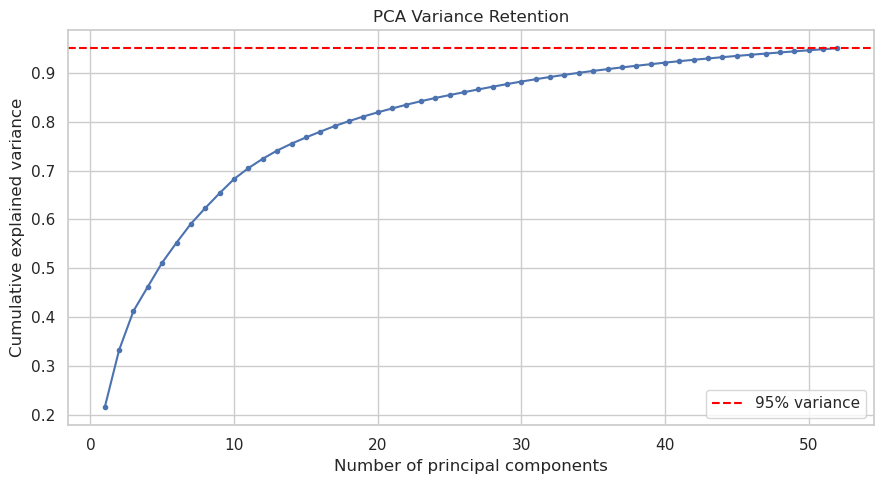

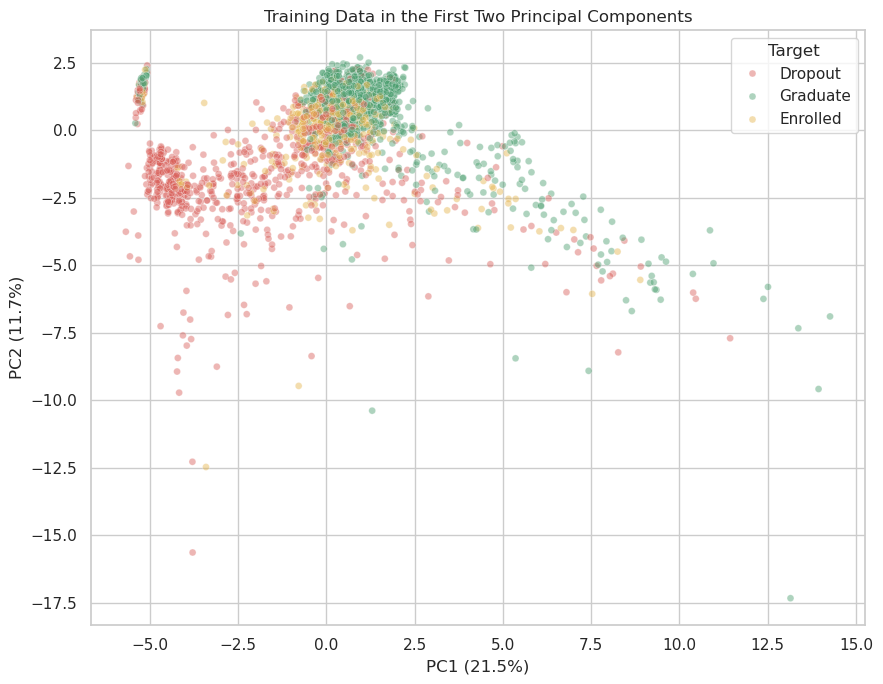


Largest absolute coefficients for PC1


,PC1
num__Curricular units 1st sem (approved),0.356120
num__Curricular units 2nd sem (approved),0.341703
num__Curricular units 1st sem (enrolled),0.301239
num__Curricular units 2nd sem (enrolled),0.295492
num__Curricular units 2nd sem (grade),0.288437
num__Curricular units 1st sem (grade),0.283160
num__Curricular units 2nd sem (evaluations),0.259313
num__Curricular units 1st sem (evaluations),0.253397
num__Curricular units 1st sem (credited),0.236335
num__Curricular units 2nd sem (credited),0.235592



Largest absolute coefficients for PC2


,PC2
num__Approval ratio 2nd sem,0.307634
num__Approval ratio 1st sem,0.284803
num__Age at enrollment,-0.260221
num__Curricular units 2nd sem (without evaluations),-0.259577
num__Curricular units 1st sem (without evaluations),-0.258426
num__Curricular units 1st sem (credited),-0.251344
num__Curricular units 2nd sem (credited),-0.246948
num__Without evaluation ratio 2nd sem,-0.233836
num__Without evaluation ratio 1st sem,-0.224222
num__Curricular units 1st sem (evaluations),-0.221916


In [55]:
pca = PCA(n_components=0.95, svd_solver="full")

X_train_pca = pca.fit_transform(X_train_prepared)
X_valid_pca = pca.transform(X_valid_prepared)
X_test_pca = pca.transform(X_test_prepared)

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

print("Original transformed features:", X_train_prepared.shape[1])
print("PCA components retained:", pca.n_components_)
print(f"Variance retained: {cumulative_variance[-1]:.2%}")

pca_variance = pd.DataFrame({
    "Component": np.arange(1, pca.n_components_ + 1),
    "Explained variance": pca.explained_variance_ratio_,
    "Cumulative variance": cumulative_variance,
})

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(
    pca_variance["Component"],
    cumulative_variance,
    marker="o",
    markersize=3,
)
ax.axhline(0.95, color="red", linestyle="--", label="95% variance")
ax.set_xlabel("Number of principal components")
ax.set_ylabel("Cumulative explained variance")
ax.set_title("PCA Variance Retention")
ax.legend()
fig.tight_layout()
fig.savefig(
    output_dir / "pca_variance.png",
    dpi=300, bbox_inches="tight"
)
plt.show()

if X_train_pca.shape[1] >= 2:
    pca_plot = pd.DataFrame({
        "PC1": X_train_pca[:, 0],
        "PC2": X_train_pca[:, 1],
        "Target": y_train_text.to_numpy(),
    })

    fig, ax = plt.subplots(figsize=(9, 7))
    sns.scatterplot(
        data=pca_plot,
        x="PC1", y="PC2",
        hue="Target",
        hue_order=outcomes,
        palette=palette,
        alpha=0.45,
        s=25,
        ax=ax,
    )
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
    ax.set_title("Training Data in the First Two Principal Components")
    fig.tight_layout()
    fig.savefig(
        output_dir / "pca_target_visualization.png",
        dpi=300, bbox_inches="tight"
    )
    plt.show()

# Inspect the strongest component coefficients.
pca_coefficients = pd.DataFrame(
    pca.components_.T,
    index=feature_names,
    columns=[f"PC{i + 1}" for i in range(pca.n_components_)],
)

for component in pca_coefficients.columns[:2]:
    strongest = (
        pca_coefficients[component]
        .abs()
        .sort_values(ascending=False)
        .head(10)
        .index
    )
    print(f"\nLargest absolute coefficients for {component}")
    display(pca_coefficients.loc[strongest, [component]])

pca_variance.to_csv(output_dir / "pca_variance.csv", index=False)
pca_coefficients.to_csv(output_dir / "pca_coefficients.csv")

### Inputs for Subsequent Model Comparison

Three candidate representations are available:

1. All preprocessed original and engineered features.
2. Features retained by embedded selection.
3. PCA components retaining at least 95% of training variance.

These alternatives will be compared using the same validation strategy.
The test set will be evaluated only after final model decisions.

For cross-validation, preprocessing, selection, and PCA must be fitted
inside each fold. Already-transformed training arrays must not be used
to bypass this requirement.

In [56]:
representation_summary = pd.DataFrame({
    "Representation": ["Full", "Selected", "PCA"],
    "Training rows": [
        X_train_prepared.shape[0],
        X_train_selected.shape[0],
        X_train_pca.shape[0],
    ],
    "Features/components": [
        X_train_prepared.shape[1],
        X_train_selected.shape[1],
        X_train_pca.shape[1],
    ],
})

display(representation_summary)

# Full original and engineered features.
full_feature_pipeline = clone(preparation_template)

# Embedded feature selection, fitted within each training fold.
selected_feature_pipeline = Pipeline([
    ("prepare", clone(preparation_template)),
    ("select", clone(selector_template)),
])

# PCA, fitted within each training fold.
pca_feature_pipeline = Pipeline([
    ("prepare", clone(preparation_template)),
    ("pca", PCA(n_components=0.95, svd_solver="full")),
])

,Representation,Training rows,Features/components
0,Full,2654,159
1,Selected,2654,27
2,PCA,2654,52


## IV. Model Implementation 

This subsection focuses on developing, testing, and comparing appropriate machine learning models based on the nature of the problem. Depending on the task, this may include supervised learning, unsupervised learning, recommendation systems, or deep learning approaches. Candidate models are evaluated using relevant performance metrics to identify the most suitable approach. To ensure reproducibility, model configurations, parameters, and generated artefacts are documented and saved systematically for future validation, comparison, and deployment.

### Model Implementation and Comparison

This study compares five classification algorithms:

| Algorithm | Justification |
|---|---|
| Dummy classifier | Establishes a majority-class baseline against which predictive models are assessed. |
| Logistic regression | Provides a regularized linear baseline and tests whether the outcomes can be distinguished through additive feature effects. |
| Random forest | Captures nonlinear relationships and interactions, such as combinations of academic performance and payment status. |
| Gradient boosting | Builds trees sequentially to improve predictions and provides a complementary nonlinear approach to random forest. |
| RBF support vector machine | Tests nonlinear decision boundaries that may help distinguish overlapping outcome groups. |

Full and selected features are compared for the tree-based models.
Logistic regression additionally evaluates PCA, while SVM compares full
features with PCA.

All candidates use identical stratified five-fold cross-validation splits
within the training set. Preprocessing, feature selection, and PCA are
fitted separately within each fold.

Macro F1 is the primary selection metric because all three outcome classes
matter and their frequencies differ. Accuracy, balanced accuracy, per-class
metrics, and confusion matrices provide additional context.

The highest training cross-validation macro F1 determines the selected
configuration. Validation results are reported as a diagnostic.
The test set is reserved for one final evaluation after selection.

These models use information through the second semester and should not
be described as enrollment-time predictions.

In [57]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    StratifiedKFold,
    GridSearchCV,
    ParameterGrid,
)
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
)
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
)

SEED = 42
N_JOBS = 2  # Reduce to 1 if memory or CPU use is excessive.

model_output_dir = Path("model_outputs")
model_output_dir.mkdir(exist_ok=True)

class_names = target_encoder.classes_
class_labels = np.arange(len(class_names))

# Materialize the splits so every experiment uses identical folds.
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED,
)
cv_splits = list(cv.split(X_train, y_train))

scoring = {
    "macro_f1": "f1_macro",
    "balanced_accuracy": "balanced_accuracy",
    "accuracy": "accuracy",
}

# Clone the unfitted feature pipelines from the preceding cell.
representations = {
    "Full": clone(full_feature_pipeline),
    "Selected": clone(selected_feature_pipeline),
    "PCA": clone(pca_feature_pipeline),
}

# Avoid nested parallelism: GridSearchCV handles parallel execution.
representations["Selected"].set_params(
    select__estimator__n_jobs=1
)

print("Training rows:", len(X_train))
print("Validation rows:", len(X_valid))
print("Test rows reserved:", len(X_test))
print("Classes:", list(class_names))

Training rows: 2654
Validation rows: 885
Test rows reserved: 885
Classes: ['Dropout', 'Enrolled', 'Graduate']


### Hyperparameter Search

Compact grids control computational cost while testing important settings:

- Logistic regression: regularization strength and class weighting.
- Random forest: tree depth, minimum leaf size, and class weighting.
- Gradient boosting: learning rate and tree depth.
- SVM: regularization strength, kernel width, and class weighting.

The selected-feature threshold remains at its previously specified value.
PCA retains at least 95% of the variance within each training fold.

The search is an initial comparison rather than an exhaustive optimization.
No resampling is applied. Class weighting is tested where directly supported
by the chosen estimator.

In [60]:
model_specs = {
    "Dummy": {
        "estimator": DummyClassifier(strategy="most_frequent"),
        "representations": ["Full"],
        "grid": {},
    },

    "Logistic regression": {
        "estimator": LogisticRegression(
            solver="lbfgs",
            max_iter=5000,
            random_state=SEED,
        ),
        "representations": ["Full", "Selected", "PCA"],
        "grid": {
            "model__C": [0.1, 1.0, 10.0],
            "model__class_weight": [None, "balanced"],
        },
    },

    "Random forest": {
        "estimator": RandomForestClassifier(
            n_estimators=200,
            max_features="sqrt",
            random_state=SEED,
            n_jobs=1,
        ),
        "representations": ["Full", "Selected"],
        "grid": {
            "model__max_depth": [None, 12],
            "model__min_samples_leaf": [2, 5],
            "model__class_weight": [None, "balanced"],
        },
    },

    "Gradient boosting": {
        "estimator": GradientBoostingClassifier(
            n_estimators=150,
            min_samples_leaf=5,
            random_state=SEED,
        ),
        "representations": ["Full", "Selected"],
        "grid": {
            "model__learning_rate": [0.05, 0.1],
            "model__max_depth": [2, 3],
        },
    },

    "RBF SVM": {
        "estimator": SVC(
            kernel="rbf",
            probability=False,
            cache_size=512,
        ),
        "representations": ["Full", "PCA"],
        "grid": {
            "model__C": [1.0, 10.0],
            "model__gamma": ["scale", 0.01],
            "model__class_weight": [None, "balanced"],
        },
    },
}

total_cv_fits = sum(
    len(spec["representations"])
    * len(ParameterGrid(spec["grid"]))
    * len(cv_splits)
    for spec in model_specs.values()
)

print(f"Planned cross-validation fits: {total_cv_fits}")
print("Additional refits train each experiment's best configuration.")

Planned cross-validation fits: 295
Additional refits train each experiment's best configuration.


### Cross-Validation and Validation Results

Each model–representation combination is tuned using training
cross-validation macro F1. Its best configuration is then evaluated on
the validation set.

Cross-validation scores are tuning estimates, not unbiased final
performance estimates. Fold standard deviations describe variability
across folds and are not confidence intervals.

A large difference between training and cross-validation scores may
indicate overfitting. Validation performance provides an additional
check, but does not alter the predefined selection rule.

In [62]:
searches = {}
validation_predictions = {}
comparison_rows = []


def evaluate_predictions(y_true, y_pred):
    report = classification_report(
        y_true,
        y_pred,
        labels=class_labels,
        target_names=class_names,
        output_dict=True,
        zero_division=0,
    )

    return {
        "Macro F1": f1_score(
            y_true, y_pred,
            labels=class_labels,
            average="macro",
            zero_division=0,
        ),
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced accuracy": balanced_accuracy_score(y_true, y_pred),
        "Dropout precision": report["Dropout"]["precision"],
        "Dropout recall": report["Dropout"]["recall"],
        "Enrolled F1": report["Enrolled"]["f1-score"],
        "Enrolled recall": report["Enrolled"]["recall"],
    }


for model_name, spec in model_specs.items():
    for representation_name in spec["representations"]:
        experiment = f"{model_name} | {representation_name}"
        print(f"\nRunning: {experiment}", flush=True)
        start = time.perf_counter()

        pipeline = Pipeline([
            ("features", clone(representations[representation_name])),
            ("model", clone(spec["estimator"])),
        ])

        search = GridSearchCV(
            estimator=pipeline,
            param_grid=spec["grid"],
            scoring=scoring,
            refit="macro_f1",
            cv=cv_splits,
            n_jobs=N_JOBS,
            pre_dispatch=N_JOBS,
            return_train_score=True,
            error_score="raise",
        )

        # Raw predictors enter the pipeline.
        search.fit(X_train, y_train)

        elapsed = time.perf_counter() - start
        predictions = search.predict(X_valid)
        validation_metrics = evaluate_predictions(y_valid, predictions)

        searches[experiment] = search
        validation_predictions[experiment] = predictions

        best_index = search.best_index_
        results = search.cv_results_

        comparison_rows.append({
            "Experiment": experiment,
            "Model": model_name,
            "Representation": representation_name,
            "CV macro F1": results["mean_test_macro_f1"][best_index],
            "CV macro F1 SD": results["std_test_macro_f1"][best_index],
            "Training macro F1": results["mean_train_macro_f1"][best_index],
            "CV balanced accuracy": (
                results["mean_test_balanced_accuracy"][best_index]
            ),
            "Validation macro F1": validation_metrics["Macro F1"],
            "Validation accuracy": validation_metrics["Accuracy"],
            "Validation balanced accuracy": (
                validation_metrics["Balanced accuracy"]
            ),
            "Validation Dropout precision": (
                validation_metrics["Dropout precision"]
            ),
            "Validation Dropout recall": (
                validation_metrics["Dropout recall"]
            ),
            "Validation Enrolled F1": validation_metrics["Enrolled F1"],
            "Validation Enrolled recall": (
                validation_metrics["Enrolled recall"]
            ),
            "Search seconds": elapsed,
            "Best parameters": search.best_params_,
        })

        safe_name = (
            experiment.lower()
            .replace(" | ", "_")
            .replace(" ", "_")
        )

        pd.DataFrame(results).to_csv(
            model_output_dir / f"cv_results_{safe_name}.csv",
            index=False,
        )

        print(
            f"CV macro F1: {search.best_score_:.3f} | "
            f"Validation macro F1: {validation_metrics['Macro F1']:.3f} | "
            f"Time: {elapsed:.1f}s",
            flush=True,
        )

comparison = (
    pd.DataFrame(comparison_rows)
    .sort_values("CV macro F1", ascending=False, kind="stable")
    .reset_index(drop=True)
)

comparison["Training–CV gap"] = (
    comparison["Training macro F1"] - comparison["CV macro F1"]
)

comparison.to_csv(
    model_output_dir / "model_comparison.csv",
    index=False,
)

display_columns = [
    "Experiment",
    "CV macro F1",
    "CV macro F1 SD",
    "Validation macro F1",
    "Validation Dropout recall",
    "Validation Enrolled F1",
    "Training–CV gap",
    "Search seconds",
]

display(comparison[display_columns].round(3))


Running: Dummy | Full
CV macro F1: 0.222 | Validation macro F1: 0.222 | Time: 3.3s

Running: Logistic regression | Full
CV macro F1: 0.708 | Validation macro F1: 0.725 | Time: 7.6s

Running: Logistic regression | Selected
CV macro F1: 0.701 | Validation macro F1: 0.710 | Time: 23.9s

Running: Logistic regression | PCA
CV macro F1: 0.703 | Validation macro F1: 0.717 | Time: 6.8s

Running: Random forest | Full
CV macro F1: 0.710 | Validation macro F1: 0.729 | Time: 21.5s

Running: Random forest | Selected
CV macro F1: 0.703 | Validation macro F1: 0.724 | Time: 46.3s

Running: Gradient boosting | Full
CV macro F1: 0.696 | Validation macro F1: 0.713 | Time: 44.0s

Running: Gradient boosting | Selected
CV macro F1: 0.679 | Validation macro F1: 0.698 | Time: 37.6s

Running: RBF SVM | Full
CV macro F1: 0.704 | Validation macro F1: 0.691 | Time: 32.0s

Running: RBF SVM | PCA
CV macro F1: 0.688 | Validation macro F1: 0.695 | Time: 20.8s


,Experiment,CV macro F1,CV macro F1 SD,Validation macro F1,Validation Dropout recall,Validation Enrolled F1,Training–CV gap,Search seconds
0,Random forest | Full,0.710,0.018,0.729,0.697,0.559,0.112,21.471
1,Logistic regression | Full,0.708,0.021,0.725,0.694,0.562,0.047,7.575
2,RBF SVM | Full,0.704,0.014,0.691,0.676,0.503,0.175,31.986
3,Random forest | Selected,0.703,0.018,0.724,0.715,0.544,0.147,46.262
4,Logistic regression | PCA,0.703,0.019,0.717,0.690,0.552,0.024,6.778
5,Logistic regression | Selected,0.701,0.021,0.710,0.655,0.544,0.010,23.915
6,Gradient boosting | Full,0.696,0.017,0.713,0.764,0.487,0.120,43.971
7,RBF SVM | PCA,0.688,0.016,0.695,0.651,0.522,0.119,20.782
8,Gradient boosting | Selected,0.679,0.020,0.698,0.761,0.459,0.185,37.619
9,Dummy | Full,0.222,0.000,0.222,0.000,0.000,-0.000,3.315


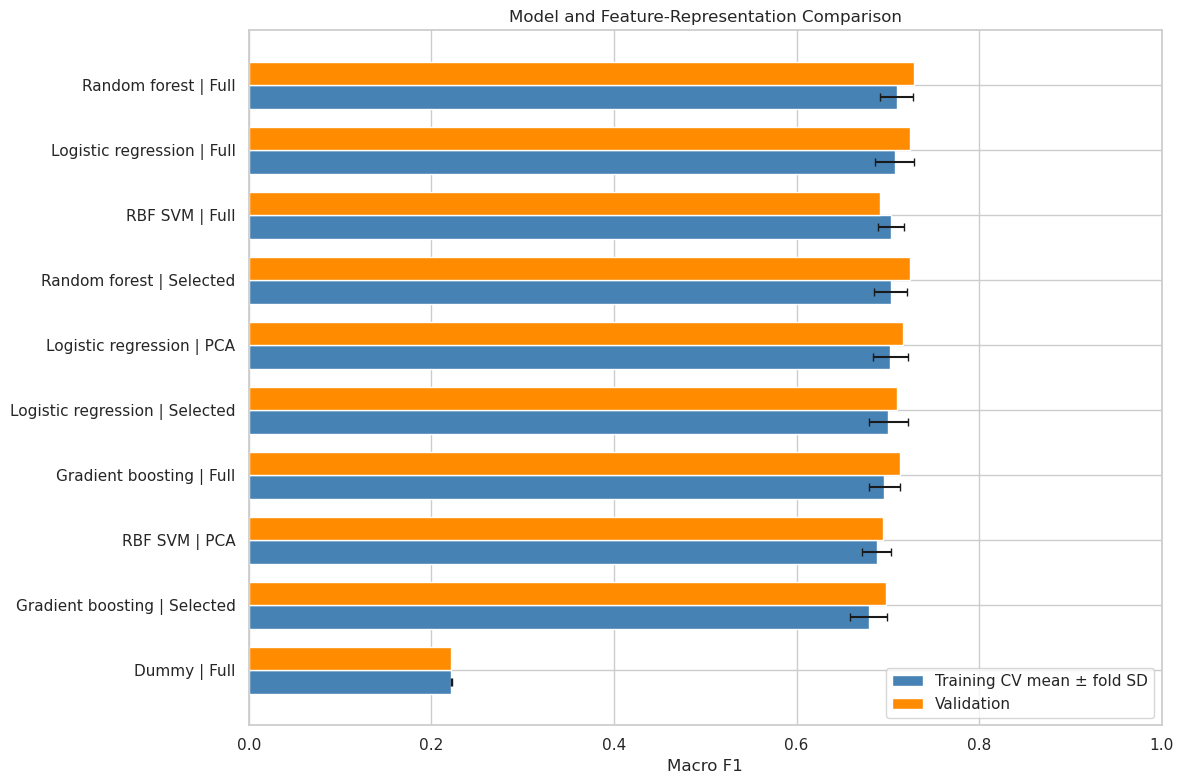

In [63]:
plot_table = comparison.sort_values("CV macro F1")
positions = np.arange(len(plot_table))
height = 0.36

fig, ax = plt.subplots(figsize=(12, 8))

ax.barh(
    positions - height / 2,
    plot_table["CV macro F1"],
    height=height,
    xerr=plot_table["CV macro F1 SD"],
    capsize=3,
    label="Training CV mean ± fold SD",
    color="steelblue",
)

ax.barh(
    positions + height / 2,
    plot_table["Validation macro F1"],
    height=height,
    label="Validation",
    color="darkorange",
)

ax.set_yticks(positions)
ax.set_yticklabels(plot_table["Experiment"])
ax.set_xlim(0, 1)
ax.set_xlabel("Macro F1")
ax.set_title("Model and Feature-Representation Comparison")
ax.legend(loc="lower right")

fig.tight_layout()
fig.savefig(
    model_output_dir / "model_comparison.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

In [64]:
representation_comparison = comparison.pivot(
    index="Model",
    columns="Representation",
    values="CV macro F1",
)

display(representation_comparison.round(3))

Representation,Full,PCA,Selected
Model,,,
Dummy,0.222,NaN,NaN
Gradient boosting,0.696,NaN,0.679
Logistic regression,0.708,0.703,0.701
RBF SVM,0.704,0.688,NaN
Random forest,0.710,NaN,0.703


### Validation Error Analysis

For each algorithm, the representation with the highest training
cross-validation macro F1 is examined using a normalized confusion matrix.

Rows represent actual outcomes and columns represent predicted outcomes.
Each row sums to one, making class-specific recall and error patterns
visible despite unequal class sizes.

Particular attention is given to Dropout students predicted as Graduate
and to confusion involving the Enrolled class.

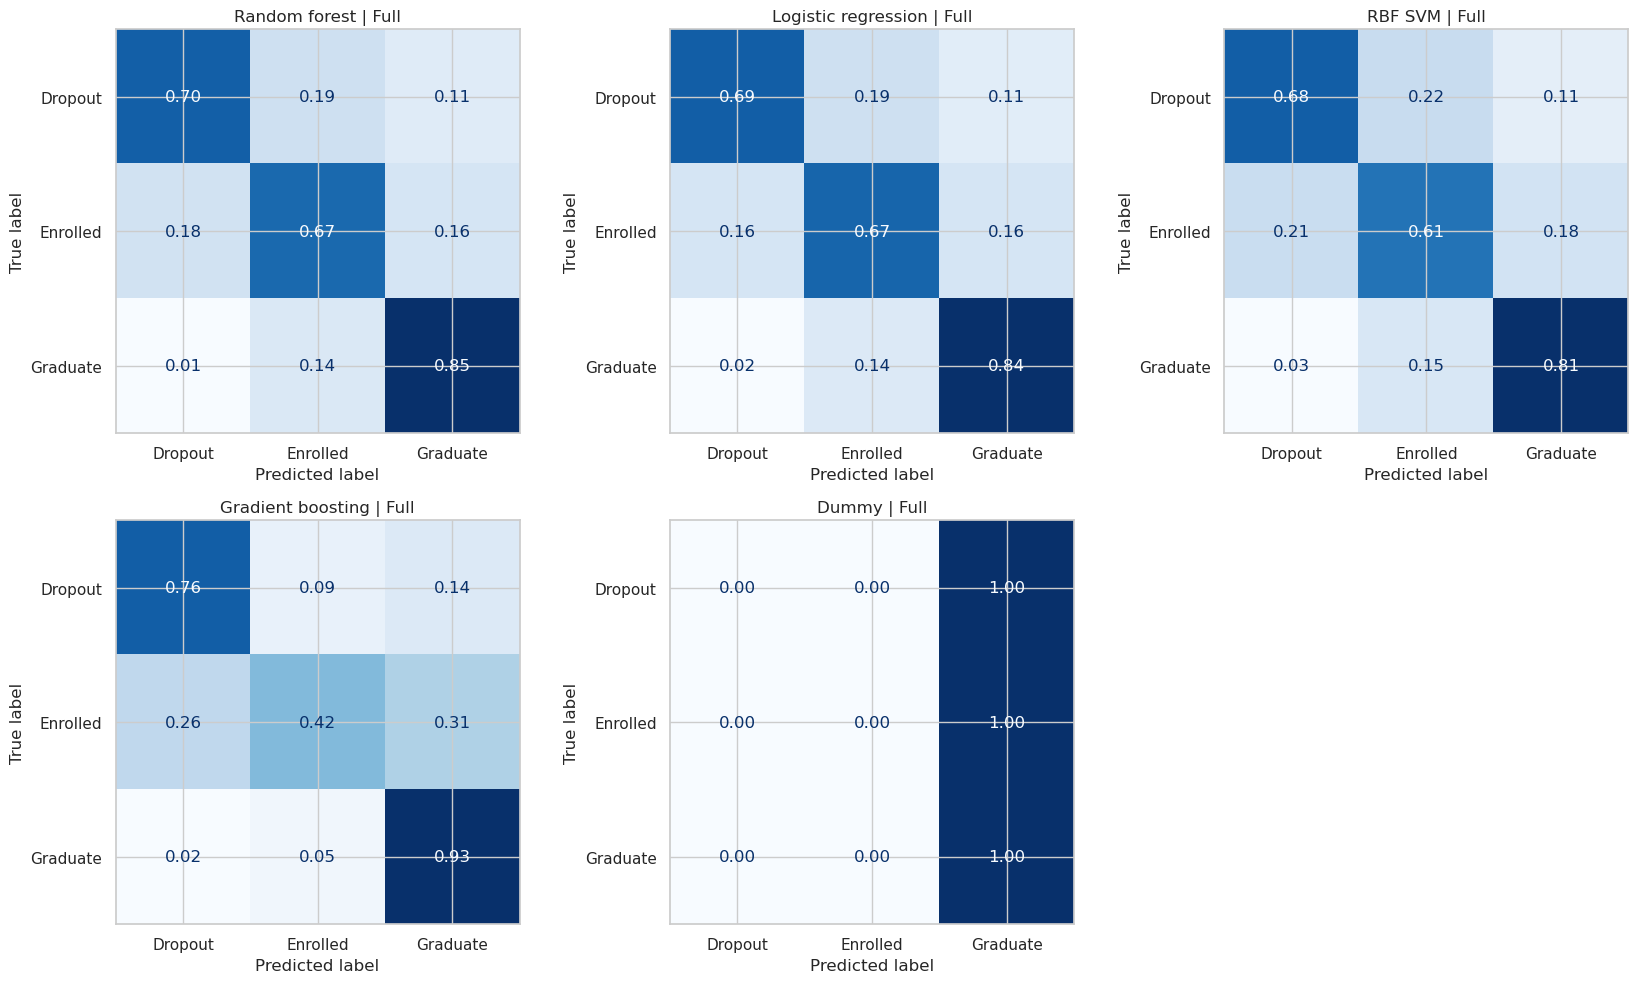

In [65]:
# comparison is already sorted by training CV macro F1.
best_per_algorithm = comparison.drop_duplicates("Model")

fig, axes = plt.subplots(2, 3, figsize=(17, 10))

for ax, (_, row) in zip(axes.flat, best_per_algorithm.iterrows()):
    experiment = row["Experiment"]

    ConfusionMatrixDisplay.from_predictions(
        y_valid,
        validation_predictions[experiment],
        labels=class_labels,
        display_labels=class_names,
        normalize="true",
        values_format=".2f",
        cmap="Blues",
        colorbar=False,
        ax=ax,
    )

    ax.set_title(experiment)

for ax in axes.flat[len(best_per_algorithm):]:
    ax.set_visible(False)

fig.tight_layout()
fig.savefig(
    model_output_dir / "validation_confusion_matrices.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

### Model Selection

The configuration with the highest mean training cross-validation macro F1
is selected. Its validation report is reviewed before final evaluation.

Small score differences do not establish that one algorithm is
statistically superior. Complexity, runtime, and error patterns are reported
alongside predictive performance.

The majority-class baseline must be exceeded before proceeding with a
predictive model.

In [67]:
winner_name = comparison.iloc[0]["Experiment"]
winner_search = searches[winner_name]

dummy_cv = comparison.loc[
    comparison["Model"].eq("Dummy"), "CV macro F1"
].iloc[0]

if winner_search.best_score_ <= dummy_cv:
    raise RuntimeError(
        "No candidate exceeds the dummy baseline. "
        "Investigate before evaluating the test set."
    )

print("Selected configuration:", winner_name)
print("Best parameters:", winner_search.best_params_)
print(f"Training CV macro F1: {winner_search.best_score_:.3f}")

print("\nValidation classification report:")
print(classification_report(
    y_valid,
    validation_predictions[winner_name],
    labels=class_labels,
    target_names=class_names,
    digits=3,
    zero_division=0,
))

validation_report = pd.DataFrame(
    classification_report(
        y_valid,
        validation_predictions[winner_name],
        labels=class_labels,
        target_names=class_names,
        output_dict=True,
        zero_division=0,
    )
).T

validation_report.to_csv(
    model_output_dir / "selected_model_validation_report.csv"
)

Selected configuration: Random forest | Full
Best parameters: {'model__class_weight': 'balanced', 'model__max_depth': 12, 'model__min_samples_leaf': 5}
Training CV macro F1: 0.710

Validation classification report:
              precision    recall  f1-score   support

     Dropout      0.853     0.697     0.767       284
    Enrolled      0.482     0.667     0.559       159
    Graduate      0.868     0.851     0.859       442

    accuracy                          0.768       885
   macro avg      0.735     0.738     0.729       885
weighted avg      0.794     0.768     0.776       885



### Final Test Evaluation

After the model configuration is fixed, the selected pipeline is refitted
on the combined training and validation data. Preprocessing, feature
selection, and PCA, where applicable, are relearned from this combined set.

The test set is evaluated once. Test results are reported without further
hyperparameter tuning or model reselection.

Earlier exploratory analysis examined the full dataset, which is a
limitation of the evaluation. Additionally, the random split measures
performance on similar observations rather than establishing performance
on future student cohorts.

,Macro F1,Accuracy,Balanced accuracy,Dropout precision,Dropout recall,Enrolled F1,Enrolled recall
Random forest | Full,0.72,0.762,0.724,0.86,0.732,0.526,0.604


              precision    recall  f1-score   support

     Dropout      0.860     0.732     0.791       284
    Enrolled      0.466     0.604     0.526       159
    Graduate      0.847     0.837     0.842       442

    accuracy                          0.762       885
   macro avg      0.724     0.724     0.720       885
weighted avg      0.782     0.762     0.769       885



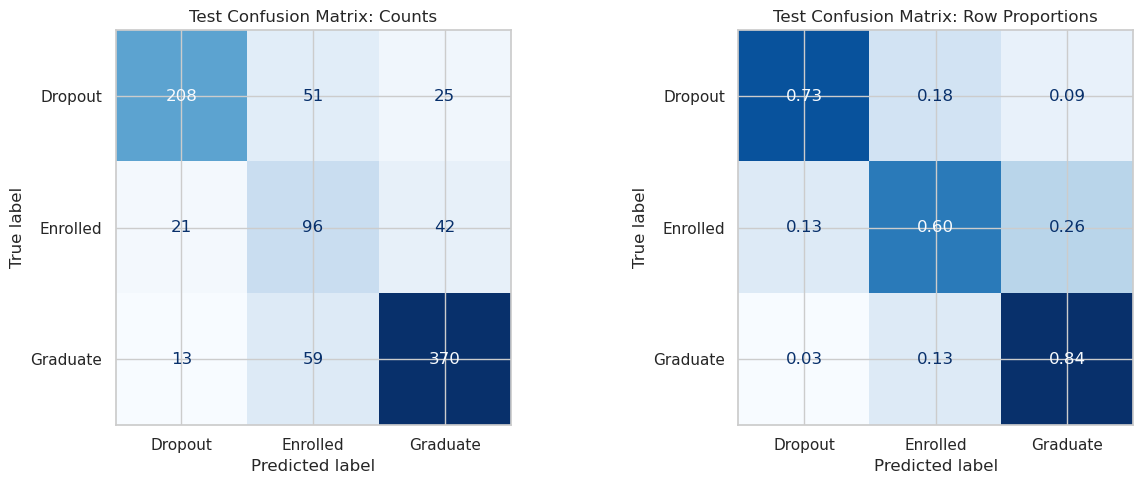

In [69]:
# Run after model decisions are fixed.
X_development = pd.concat([X_train, X_valid], axis=0)
y_development = np.concatenate([y_train, y_valid])

# Clone removes fitted state but preserves the chosen configuration.
final_model = clone(winner_search.best_estimator_)
final_model.fit(X_development, y_development)

test_predictions = final_model.predict(X_test)

test_metrics = evaluate_predictions(y_test, test_predictions)
test_metrics_table = pd.DataFrame(
    [test_metrics],
    index=[winner_name],
)

display(test_metrics_table.round(3))

print(classification_report(
    y_test,
    test_predictions,
    labels=class_labels,
    target_names=class_names,
    digits=3,
    zero_division=0,
))

test_report = pd.DataFrame(
    classification_report(
        y_test,
        test_predictions,
        labels=class_labels,
        target_names=class_names,
        output_dict=True,
        zero_division=0,
    )
).T

test_metrics_table.to_csv(
    model_output_dir / "final_test_metrics.csv"
)
test_report.to_csv(
    model_output_dir / "final_test_classification_report.csv"
)

# Save original class names for interpretation.
prediction_table = pd.DataFrame({
    "Actual": target_encoder.inverse_transform(np.asarray(y_test)),
    "Predicted": target_encoder.inverse_transform(test_predictions),
}, index=X_test.index)

prediction_table.index.name = "Original row index"
prediction_table.to_csv(
    model_output_dir / "final_test_predictions.csv"
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_predictions,
    labels=class_labels,
    display_labels=class_names,
    cmap="Blues",
    colorbar=False,
    ax=axes[0],
)
axes[0].set_title("Test Confusion Matrix: Counts")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_predictions,
    labels=class_labels,
    display_labels=class_names,
    normalize="true",
    values_format=".2f",
    cmap="Blues",
    colorbar=False,
    ax=axes[1],
)
axes[1].set_title("Test Confusion Matrix: Row Proportions")

fig.tight_layout()
fig.savefig(
    model_output_dir / "final_test_confusion_matrices.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

### Model Results Interpretation

The **random forest using the full feature representation** achieved the highest mean cross-validation macro F1 (0.710), narrowly exceeding logistic regression (0.708). Feature selection and PCA did not improve cross-validation performance in the evaluated configurations. After refitting on the combined training and validation sets, the selected model achieved a test macro F1 of 0.720, accuracy of 76.2%, and balanced accuracy of 72.4%. Performance was strongest for Graduate students (F1 = 0.842), followed by Dropout students (F1 = 0.791). Enrolled students remained difficult to distinguish (F1 = 0.526). The model identified 73.2% of actual dropouts with 86.0% precision, while missing 76 of 284 dropout cases. These results support the model’s predictive value within the evaluated setting, but do not establish performance on future cohorts or at enrollment time.

## V. Bias & Fairness Analysis

This subsection evaluates the model beyond predictive performance by examining its interpretability, limitations, and potential ethical risks. Model decisions are explained using techniques such as SHAP, LIME, Partial Dependence Plots (PDP), and Individual Conditional Expectation (ICE), while issues such as class imbalance, data leakage, and overfitting are critically assessed. Bias and fairness audits are also conducted by comparing model outcomes across relevant sensitive groups and applying fairness metrics such as demographic parity, equalized odds, and disparate impact. Where potential biases are identified, appropriate mitigation strategies—such as reweighting, threshold adjustment, data augmentation, or post-processing—are proposed.

### Ethical AI, Explainability, and Fairness Audit

The model is intended to support student assistance, not to determine
admission, impose penalties, or restrict educational opportunities.
Predictions should inform human review rather than replace it.

A dropout prediction could trigger supportive outreach. False negatives
may withhold assistance from students who need it, while false positives
may cause unnecessary intervention or stigma. Both error types matter.

The following limitations apply:

- Class imbalance: Enrolled students are less represented and have the
  lowest test F1 (0.526). Overall accuracy can conceal this weakness.
- Missed dropouts: The model identified 208 of 284 actual dropouts,
  leaving 76 undetected.
- Overfitting: Random forest training macro F1 exceeded cross-validation
  macro F1 by approximately 0.112.
- Leakage and timing: Semester results and payment information must be
  available before the outcome being predicted. This is not an
  enrollment-time model.
- Evaluation: Earlier EDA examined the full dataset. A random split also
  does not establish generalization to future cohorts or institutions.
- Label limitations: Enrolled describes an observed status, not a
  confirmed eventual graduation or dropout outcome.
- Probability interpretation: Random forest probability estimates have
  not been calibrated and should not be treated as exact individual risks.

This audit describes the fixed model's behaviour on the test set.
Any mitigation developed in response requires separate evaluation data;
the current test set must not become a tuning set.

In [71]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.inspection import PartialDependenceDisplay
from sklearn.metrics import accuracy_score, f1_score

audit_dir = Path("ethical_ai_outputs")
audit_dir.mkdir(exist_ok=True)

SEED = 42
MIN_GROUP_SIZE = 30
MIN_CLASS_COUNT = 10

# Preserve positional alignment with y_test.
X_audit = X_test.copy().reset_index(drop=True)
y_audit = np.asarray(y_test)
pred_audit = final_model.predict(X_audit)

class_names = target_encoder.classes_
class_labels = target_encoder.transform(class_names)

assert len(X_audit) == len(y_audit) == len(pred_audit)

print("Audit observations:", len(X_audit))
print("Outcomes:", list(class_names))

Audit observations: 885
Outcomes: ['Dropout', 'Enrolled', 'Graduate']


### Partial Dependence and Individual Conditional Expectation

Partial dependence plots (PDP) show the average predicted dropout
probability as one feature is varied. Individual conditional expectation
(ICE) curves show how this response differs across sampled students.

The explanations use the final fitted pipeline. Derived features are
recomputed when an original feature changes.

These plots describe model behaviour, not causal effects or guaranteed
benefits from changing a feature. Correlated predictors can produce
unrealistic combinations, such as changing approved units while leaving
grades and enrolled units fixed. Individual ICE curves are not complete
explanations of a student's prediction.

/opt/conda/lib/python3.12/site-packages/sklearn/inspection/_partial_dependence.py:721: FutureWarning: The column 30 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/sklearn/inspection/_partial_dependence.py:721: FutureWarning: The column 24 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/sklearn/inspection/_partial_dependence.py:721: FutureWar

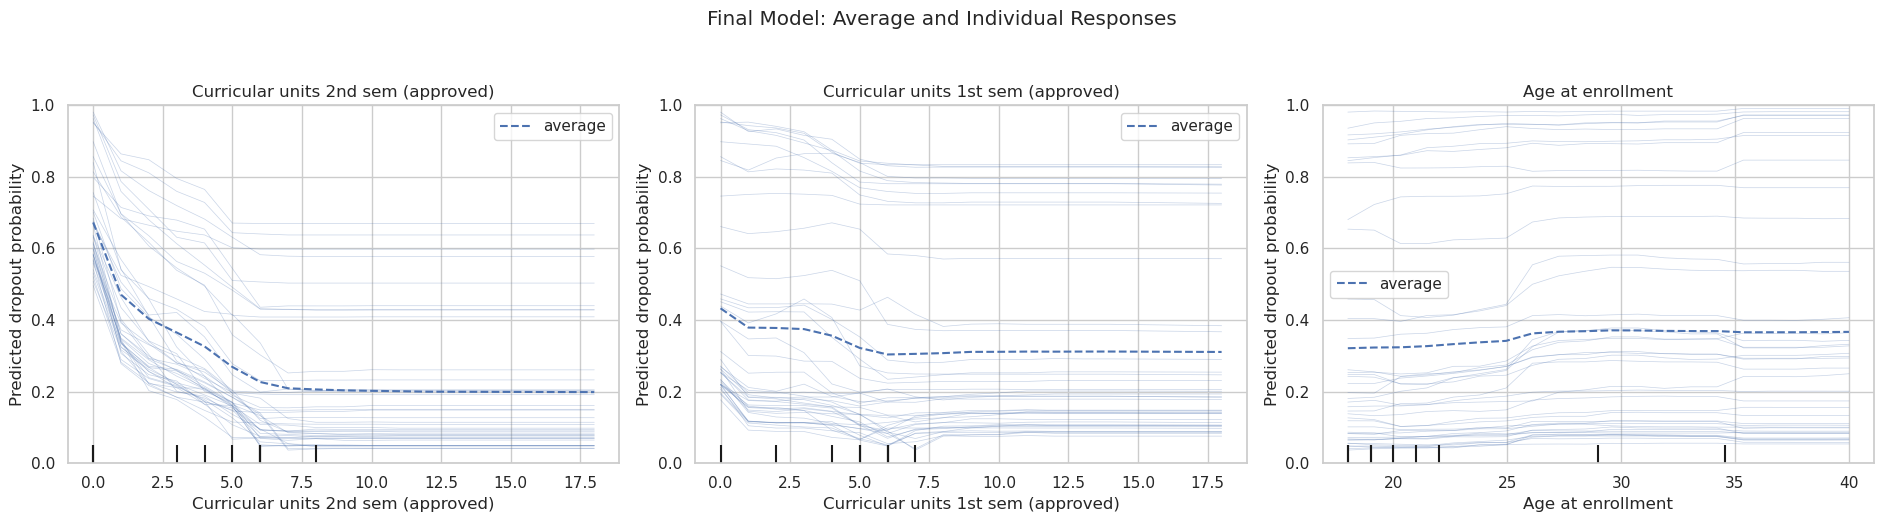

In [73]:
dropout_label = int(target_encoder.transform(["Dropout"])[0])

# Use development data for explanation; no refitting occurs.
X_explain = pd.concat([X_train, X_valid], axis=0).sample(
    n=min(300, len(X_train) + len(X_valid)),
    random_state=SEED,
).copy()

explanation_features = [
    "Curricular units 2nd sem (approved)",
    "Curricular units 1st sem (approved)",
    "Age at enrollment",
]

fig, axes = plt.subplots(1, 3, figsize=(19, 5))

PartialDependenceDisplay.from_estimator(
    final_model,
    X_explain,
    features=explanation_features,
    target=dropout_label,
    response_method="predict_proba",
    method="brute",
    kind="both",
    subsample=40,
    grid_resolution=20,
    percentiles=(0.05, 0.95),
    random_state=SEED,
    n_jobs=1,
    ax=axes,
)

for ax, feature in zip(axes, explanation_features):
    ax.set_title(feature, wrap=True)
    ax.set_ylabel("Predicted dropout probability")
    ax.set_ylim(0, 1)

fig.suptitle("Final Model: Average and Individual Responses", y=1.04)
fig.tight_layout()
fig.savefig(
    audit_dir / "final_model_pdp_ice.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

### Interpretation of PDP and ICE Results

Second-semester approved units produce the strongest response in the
plotted model predictions. The average predicted dropout probability falls
from approximately 0.67 at zero approved units to approximately 0.20 at
seven units, then remains relatively stable.

First-semester approved units show a smaller response: the average
predicted dropout probability decreases from approximately 0.43 at zero
units to approximately 0.30 at six units.

Age has a comparatively modest average effect. Predicted dropout
probability increases from approximately 0.32 in the late teenage years
to approximately 0.37 in the late twenties, then changes little.
Individual ICE curves differ substantially, indicating that the model's
response depends on other student characteristics.

These curves describe the fitted pipeline's behaviour, including changes
to derived features such as approval ratios. They are not observed dropout
rates or causal effects. Increasing approved units in the plot does not
demonstrate that an intervention would produce the same reduction in risk.

Academic predictors are correlated. Changing approved units while holding
grades and enrolled units fixed can generate unrealistic combinations.
Interpretation is also less reliable in sparsely represented regions.

The relatively small age PDP response does not establish age fairness:
group-level prediction errors can differ through other correlated features.

### Sensitive Attributes and Audit Coverage

The audit examines:

- Recorded gender, retaining the dataset's codes without inferring identity.
- Age groups: under 20, 20–24, 25–34, and 35+.
- Scholarship status, debtor status, and tuition-payment status as
  socioeconomic proxies.
- Gender-by-age intersections to identify disparities hidden by broad groups.

Race or ethnicity is not recorded and cannot be audited directly.
Nationality is not treated as a substitute for race.

The financial variables do not directly measure household income or
socioeconomic status. Differences across these proxies must be described
as such. Missing group values are retained as an explicit audit category.

In [75]:
def recorded_codes(series):
    """Keep recorded codes; avoid inventing category meanings."""
    return series.astype("string").fillna("Missing")


groups = pd.DataFrame(index=X_audit.index)

groups["Gender"] = recorded_codes(X_audit["Gender"])

groups["Age group"] = (
    pd.cut(
        pd.to_numeric(X_audit["Age at enrollment"], errors="raise"),
        bins=[-np.inf, 20, 25, 35, np.inf],
        labels=["Under 20", "20–24", "25–34", "35+"],
        right=False,
    )
    .astype("string")
    .fillna("Missing")
)

for column in ["Scholarship holder", "Debtor", "Tuition fees up to date"]:
    groups[column] = recorded_codes(X_audit[column])

groups["Gender × Age"] = (
    "Gender " + groups["Gender"] + " / " + groups["Age group"]
)

coverage = pd.concat(
    [
        groups[column].value_counts(dropna=False)
        .rename_axis("Group")
        .reset_index(name="Count")
        .assign(Attribute=column)
        for column in groups.columns
    ],
    ignore_index=True,
)[["Attribute", "Group", "Count"]]

display(coverage)
coverage.to_csv(audit_dir / "audit_group_counts.csv", index=False)

,Attribute,Group,Count
0,Gender,0,571
1,Gender,1,314
2,Age group,Under 20,376
3,Age group,20–24,274
4,Age group,25–34,154
5,Age group,35+,81
6,Scholarship holder,0,652
7,Scholarship holder,1,233
8,Debtor,0,767
9,Debtor,1,118


### Fairness Metric Definitions

Each outcome is audited separately using a one-versus-rest comparison.
For example, Dropout is treated as the positive label when auditing
dropout predictions.

For each group:

- Selection rate: proportion predicted as the specified outcome.
- Observed outcome rate: proportion actually belonging to that outcome.
- True positive rate (TPR/recall): proportion of actual positive cases
  correctly identified.
- False positive rate (FPR): proportion of actual negative cases
  incorrectly assigned the positive label.
- False negative rate (FNR): proportion of actual positive cases missed.

Across groups:

- Demographic parity difference:
  highest selection rate minus lowest selection rate.
- Disparate-impact-style ratio:
  lowest selection rate divided by highest selection rate.
  This is a symmetric comparison without a predefined reference group.
- Equalised odds difference:
  the larger of the between-group TPR gap and FPR gap.

Smaller differences and ratios closer to one indicate closer parity,
but do not establish that a system is fair.

Different observed outcome rates can create tension between fairness
criteria. Equal prediction rates alone do not guarantee equal access
to appropriate support.

For Dropout, "selection" means receiving the dropout label, not receiving
a favourable outcome. The implications depend on what action follows
the prediction. No automatic legal or fairness pass/fail threshold is used.

In [77]:
def safe_divide(numerator, denominator):
    return numerator / denominator if denominator > 0 else np.nan


def wilson_interval(successes, total, z=1.96):
    """Approximate 95% interval for a binomial proportion."""
    if total == 0:
        return np.nan, np.nan

    proportion = successes / total
    denominator = 1 + z**2 / total

    centre = (proportion + z**2 / (2 * total)) / denominator
    half_width = (
        z
        * np.sqrt(
            proportion * (1 - proportion) / total
            + z**2 / (4 * total**2)
        )
        / denominator
    )

    return max(0, centre - half_width), min(1, centre + half_width)


metric_rows = []

for attribute in groups.columns:
    for group_name, positions in groups.groupby(
        attribute, sort=True
    ).indices.items():

        actual = y_audit[positions]
        predicted = pred_audit[positions]

        for outcome, label in zip(class_names, class_labels):
            actual_positive = actual == label
            predicted_positive = predicted == label

            tp = int(np.sum(actual_positive & predicted_positive))
            fn = int(np.sum(actual_positive & ~predicted_positive))
            fp = int(np.sum(~actual_positive & predicted_positive))
            tn = int(np.sum(~actual_positive & ~predicted_positive))

            n = len(actual)
            positives = tp + fn
            negatives = fp + tn
            predicted_positives = tp + fp

            selection_low, selection_high = wilson_interval(
                predicted_positives, n
            )
            tpr_low, tpr_high = wilson_interval(tp, positives)
            fpr_low, fpr_high = wilson_interval(fp, negatives)

            metric_rows.append({
                "Attribute": attribute,
                "Group": group_name,
                "Outcome": outcome,
                "Count": n,
                "Actual positives": positives,
                "Actual negatives": negatives,
                "Predicted positives": predicted_positives,
                "TP": tp,
                "FN": fn,
                "FP": fp,
                "TN": tn,
                "Observed outcome rate": safe_divide(positives, n),
                "Selection rate": safe_divide(predicted_positives, n),
                "Selection low": selection_low,
                "Selection high": selection_high,
                "TPR": safe_divide(tp, positives),
                "TPR low": tpr_low,
                "TPR high": tpr_high,
                "FPR": safe_divide(fp, negatives),
                "FPR low": fpr_low,
                "FPR high": fpr_high,
                "FNR": safe_divide(fn, positives),
                "Precision": safe_divide(tp, predicted_positives),
                "Group accuracy": accuracy_score(actual, predicted),
                "Group macro F1": f1_score(
                    actual,
                    predicted,
                    labels=class_labels,
                    average="macro",
                    zero_division=0,
                ),
                "Small group": n < MIN_GROUP_SIZE,
                "Sparse outcome support": (
                    positives < MIN_CLASS_COUNT
                    or negatives < MIN_CLASS_COUNT
                ),
            })

group_metrics = pd.DataFrame(metric_rows)

display_columns = [
    "Attribute", "Group", "Outcome", "Count",
    "Actual positives", "Actual negatives",
    "Observed outcome rate", "Selection rate",
    "TPR", "FPR", "FNR", "Precision",
    "Small group", "Sparse outcome support",
]

display(
    group_metrics.loc[
        group_metrics["Outcome"].eq("Dropout"),
        display_columns,
    ].round(3)
)

group_metrics.to_csv(
    audit_dir / "fairness_group_metrics_all_outcomes.csv",
    index=False,
)

,Attribute,Group,Outcome,Count,Actual positives,Actual negatives,Observed outcome rate,Selection rate,TPR,FPR,FNR,Precision,Small group,Sparse outcome support
0,Gender,0,Dropout,571,134,437,0.235,0.193,0.701,0.037,0.299,0.855,False,False
3,Gender,1,Dropout,314,150,164,0.478,0.420,0.760,0.110,0.240,0.864,False,False
6,Age group,20–24,Dropout,274,79,195,0.288,0.226,0.684,0.041,0.316,0.871,False,False
9,Age group,25–34,Dropout,154,91,63,0.591,0.565,0.868,0.127,0.132,0.908,False,False
12,Age group,35+,Dropout,81,39,42,0.481,0.457,0.872,0.071,0.128,0.919,False,False
15,Age group,Under 20,Dropout,376,75,301,0.199,0.149,0.547,0.050,0.453,0.732,False,False
18,Scholarship holder,0,Dropout,652,256,396,0.393,0.333,0.746,0.066,0.254,0.880,False,False
21,Scholarship holder,1,Dropout,233,28,205,0.120,0.107,0.607,0.039,0.393,0.680,False,False
24,Debtor,0,Dropout,767,212,555,0.276,0.232,0.703,0.052,0.297,0.837,False,False
27,Debtor,1,Dropout,118,72,46,0.610,0.542,0.819,0.109,0.181,0.922,False,False


### Interpretation of the Fairness Audit

The audit covers 885 test observations. The table below summarizes
Dropout-versus-rest comparisons. Differences are expressed in percentage
points (pp); selection ratios compare the lowest with the highest group
prediction rate.

| Attribute | Demographic parity gap (pp) | Selection min/max ratio | TPR gap (pp) | FPR gap (pp) | Equalised odds gap (pp) |
|---|---:|---:|---:|---:|---:|
| Gender | 22.8 | 0.458 | 5.9 | 7.3 | 7.3 |
| Age group | 41.6 | 0.264 | 32.5 | 8.6 | 32.5 |
| Scholarship status | 22.6 | 0.322 | 13.9 | 2.7 | 13.9 |
| Debtor status | 31.0 | 0.428 | 11.7 | 5.6 | 11.7 |
| Tuition-payment status | 72.6 | 0.202 | 37.0 | 42.1 | 42.1 |
| Gender × age | 59.8 | 0.165 | 39.7 | 23.4 | 39.7 |

The largest observed dropout equalised odds gaps occur across
tuition-payment status, gender-by-age intersections, and age groups.
These are descriptive disparities, not statistical significance tests
or proof of discrimination.

#### Gender

Gender category 1 has a higher predicted dropout rate than category 0:
42.0% versus 19.3%. Their observed dropout rates also differ substantially:
47.8% versus 23.5%.

Dropout recall is 76.0% for category 1 and 70.1% for category 0.
The false-positive rate is 11.0% versus 3.7%, indicating that non-dropout
students in category 1 are more frequently assigned the dropout label.

Different observed outcome rates help contextualize the prediction-rate
gap but do not automatically justify the difference in error rates.

#### Age

Dropout recall is only 54.7% among students under 20, compared with
68.4% for ages 20–24, 86.8% for ages 25–34, and 87.2% for ages 35+.

The model misses 34 of the 75 actual dropouts under 20.
If dropout predictions trigger assistance, this creates a potential
under-identification problem for younger students.

#### Socioeconomic Proxies

Scholarship holders have lower dropout recall than non-holders:
60.7% versus 74.6%. However, only 28 scholarship holders are actual
dropouts, making this estimate less precise.

Debtors have higher dropout recall than non-debtors:
81.9% versus 70.3%. Their false-positive rate is also higher:
10.9% versus 5.2%.

Tuition-payment status shows the largest disparities. Students whose fees
are not up to date have a 90.9% predicted dropout rate, compared with
18.3% among students whose fees are up to date.

Dropout recall is 97.9% versus 60.8%, while the false-positive rate is
46.7% versus 4.6%. The 46.7% estimate represents seven false positives
among only 15 actual non-dropouts with outstanding fees, so uncertainty
is substantial.

These variables are financial-status proxies, not direct measures of
household income or socioeconomic position. Their measurement timing
also requires verification.

#### Intersectional Patterns

Gender-by-age comparisons reveal differences hidden by overall gender
results. Dropout recall ranges from 51.6% for Gender 1 / Under 20
to 91.3% for Gender 1 / 35+.

The Gender 1 / 25–34 group has a 26.3% false-positive rate, representing
five errors among 19 actual non-dropouts.

Intersectional group sizes range from 36 to 271 students. Although all
exceed the 30-observation screening threshold, some outcome-specific
denominators remain small. Passing a sample-size flag does not guarantee
a precise estimate.

#### Other Outcomes

Disparities also occur for Enrolled and Graduate predictions.

For Enrolled, the equalised odds gap is 28.3 pp across age groups and
47.9 pp across gender-by-age groups. The intersectional comparison has
sparse outcome support and requires cautious interpretation.

For Graduate, the equalised odds gap is 34.3 pp across tuition-payment
groups, again with sparse outcome support.

The audit therefore identifies uneven performance across multiple
outcomes, rather than a concern limited to dropout predictions.

### Mitigation Priorities Based on the Audit

1. Improve identification of younger students who eventually drop out.
   Evaluate recall by age and gender-by-age groups during development.
   Consider additional timely academic-engagement information and
   supportive outreach pathways that do not depend solely on a dropout label.

2. Investigate reliance on tuition-payment information.
   Verify that payment status was measured before the predicted outcome.
   Compare models with and without payment-related predictors using
   development data. Outstanding fees should prompt consideration of
   financial assistance, not punitive action.

3. Evaluate reweighting and decision policies.
   Test group-by-outcome training weights and development-set dropout
   thresholds against both missed-dropout and false-alert costs.
   Class balancing alone has not eliminated group disparities.

4. Strengthen evidence for small subgroups.
   Seek additional representative observations, particularly for
   intersectional groups and uncommon outcomes within payment categories.
   Synthetic augmentation cannot substitute for representative evidence.

5. Evaluate post-processing cautiously.
   Group-specific thresholds or equalised-odds post-processing may alter
   fairness metrics but introduce trade-offs. They require explicit review
   of the intended intervention and its ethical and operational implications.

6. Preserve independent evaluation.
   These test-set findings are diagnostic. Any resulting model changes
   should be developed through training-only validation and assessed on
   new untouched data. The current test set must not be reused as an
   independent confirmation of improvement.

### Ethical AI Audit Conclusion

The final random forest achieved a test macro F1 of 0.720 and accuracy
of 76.2%, but its performance was not uniform across student groups.

PDP and ICE results showed that academic progress, particularly
second-semester approved units, strongly influenced model predictions.
Age had a smaller average response, although substantial age-related
differences appeared in group-level error rates.

The fairness audit identified notable dropout equalised odds gaps across
tuition-payment status (42.1 percentage points), gender-by-age groups
(39.7 points), and age groups (32.5 points). Students under 20 had only
54.7% dropout recall, indicating a risk of missing younger students who
might need assistance.

Students with outstanding tuition fees were much more frequently predicted
to drop out and had a higher false-positive rate. However, this
false-positive estimate was based on only 15 actual non-dropouts.
Group counts and uncertainty must therefore accompany disparity estimates.

These findings demonstrate unequal observed prediction and error rates,
but do not establish causal discrimination. Differences in observed
outcomes, correlated predictors, data quality, and measurement timing
require further investigation. No single fairness metric is sufficient
to declare the model fair.

Race-based fairness could not be assessed because race or ethnicity was
not recorded. Scholarship, debtor, and tuition-payment status were audited
as imperfect socioeconomic proxies rather than direct socioeconomic
measurements.

The model should be considered a candidate support tool requiring further
validation, not an autonomous decision system. Predictions should support
non-punitive assistance with human review, opportunities for correction,
and monitoring of who actually receives help.

Any mitigation should be evaluated jointly for predictive performance,
group-specific errors, and intervention outcomes on fresh data.